<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# Week 10 — Black-box Optimisation, Functions 1–8 

- success: F1, F3, F4, F5, F7, F8
- fail: F2, F6

| **#** | **Optimisation Strategy** | **Key Assumption** | **Main Data Gap / Bias** | **Key Limitation** |
|----------|-----------------------|----------------|----------------------|----------------|
| **F1** | GP with UCB/EI acquisition and Signed, monotonic transform | Follow Week 9 method | Low robustness | Sensible exploitation rather than a wide, poorly-calibrated jump. |
| **F2** | GP (Matern + White) + posterior-mean maximisation (multi-start L-BFGS-B), plus a manual local search | Pure exploitation; domain extended to 1.2 | Queries cluster along one narrowing path | Target **[0.70, 0.10]** vs. plot label **[0.69, 0.20]** mismatch |
| **F3** | ExtraTrees (`log(-Y)`, polynomial features) + LCB (κ = 0.3) | `log(-Y)` transform used before it was validated | Two weekly queries are exact duplicates | Transform breaks if **Y ≥ 0**; validation came too late |
| **F4** | GP (Matern, fixed length-scale) + EI computed, compare `np.argmax(mu)` and `np.argmax(ei)` | Candidates biased toward W7/W8 neighbourhoods | Training mixes very different output regimes | mu is used, so the result is 100% greedy, never explores unseen regions if the local mean is high. EI computed for comparison only. |
| **F5** | SVR pre-filter → GP (`log1p`, Matern) + UCB (κ = 2.5); compare `np.argmax(mu_log)` and `np.argmax(ucb)` | Candidates deliberately pushed beyond **[0,1]** to **2.0** | No data exists above **1.0** for any input | `np.argmax(mu_log)` is selected for safe option |
| **F6** | Two-stage LHS (global + local refinement) scored by GP (isotropic Matern) + UCB (κ = 2.5); SVR fit but unused for acquisition | Isotropic length-scale (reverted from ARD) | SHAP computed but disconnected from search | Local refinement may miss a distant 5D optimum |
| **F7** | Two-stage RF filtering (full RF → HP1-filtered RF) → GP (`sqrt(Y)`, Matern + DotProduct) + custom EI on the original scale | Low-HP1 subset assumed to hold the optimum | Filtered RF trained on very few points | **100k → 10k → 1k** funnel permanently excludes ~99% of the search space |
| **F8** | MC-Dropout MLP (weighted loss) + LHS candidate pool (50k) + UCB (adaptive κ from LOO calibration) | Up-weighting high-*y* points improves precision | Weighting thresholds set after seeing the data | SHAP importance computed but unused this week |

> This is Module 21: Transparency and Interpretability. Revisit previous weeks.

| **#**                      | **Previous Weeks (W3–W9) Summary**                                                                                                                                                                 | **Week 10 Strategy**                                                                                                                                                          |
| ----------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **F1**      | Progressed from EI + diversity hybrid (W3) → GP + UCB variants with shifting κ and length-scale treatments (W4–W8), with W4 and W7 flagged. | Followed Week-9, sensible exploitation rather than a wide, poorly-calibrated jump.                          |
| **F2** | EI + diversity (W3) → GP + Thompson sampling (W4) → RF-based greedy/Thompson approaches (W5–W7) → anisotropic GP + UCB (κ = 0.1) (W8).                                                         | GP (Matérn + White) + posterior-mean maximisation (multi-start L-BFGS-B) with domain extended to 1.2, plus a manual local search near a target point.                     |
| **F3**       | Mixed exploration/exploitation (W3) → GP EI blended with polynomial surrogate (W4) → RF/ExtraTrees on polynomial features with argmax or weighted LCB (W5–W8).                                 | ExtraTrees on log(-Y) + polynomial features, with LCB acquisition (κ = 0.3).                                                                                              |
| **F4**   | Exploration-heavy UCB (W3) → GP + Thompson (W4) → RF/SVM-gated approaches (W5–W7) → GP (model-selected via LOO R²) + UCB (κ = 0.5) (W8).                                                       | GP (Matérn, fixed length-scale) with EI computed, but query actually selected via `argmax(mu)`— for safe and Pure Exploitation, rather than Expected Improvement.                             |
| **F5**     | Strong SVR-based exploitation (W3) → SVR pre-filter + GP EI pipeline, progressively refined (W4–W8), consistently using ξ = 0.005.                                                             | SVR pre-filter → GP (`log1p`, Matérn) + UCB (κ = 2.5); candidates deliberately pushed beyond [0,1] to 2.0; `argmax(mu)` is chosen over EI |
| **F6**          | ARD GP + EI (W3–W4) → RF surrogates with Thompson sampling/UCB (W5–W7) → hybrid GP + RF blend + EI (W8).                                                                                       | Two-stage LHS (global + local refinement) scored by GP (isotropic Matérn) + UCB (κ = 2.5); SVR fit but not used for acquisition.                                          |
| **F7**    | RF-driven exploitation with SHAP (W3) → GP + MLP blend (W4) → RBF/RF two-stage reranking (W5) → RF-narrowed subspace + GP/UCB (W6–W8).                                                         | Two-stage RF filtering (100k → 10k → 1k) → GP (`sqrt(Y)`, Matérn + DotProduct) with custom EI computed on the original output scale.                                      |
| **F8**    | Mixed exploration/exploitation pipelines (W3) → GP + MLP blend (W4) → MC-Dropout MLP with UCB, increasingly refined dropout/κ/SHAP scaling (W5–W8).                                            | MC-Dropout MLP (weighted loss, increased capacity) + LHS candidate pool (50k) + UCB with adaptive κ (from LOO calibration).                                               |


In [1]:
# -----------------------------------------------------------------------------
# Imports
# -----------------------------------------------------------------------------

import warnings

import matplotlib.pyplot as plt
import numpy as np
import shap
import torch
import torch.nn as nn
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
from scipy.stats import norm, rankdata
from scipy.stats.qmc import LatinHypercube
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel,
    DotProduct,
    Matern,
    WhiteKernel,
)
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVC, SVR
from skopt.sampler import Lhs
from skopt.space import Space


# -----------------------------------------------------------------------------
# Warning configuration
# -----------------------------------------------------------------------------

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Helper Functions

In [2]:
def compute_ucb(mu, sigma, kappa=2.5):
    return mu + kappa * sigma
 
def compute_ei(mu, sigma, f_best, xi=0.01):
    z = (mu - f_best - xi) / (sigma + 1e-9)
    ei = (mu - f_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma == 0] = 0
    return ei
 
def format_query(point, decimals=6):
    return '-'.join([f'{x:.{decimals}f}' for x in point])
 
def thompson_sample(gp, candidates, n_samples=10, subsample=500):
    idx = np.random.choice(len(candidates), size=min(subsample, len(candidates)), replace=False)
    sub = candidates[idx]
    samples = gp.sample_y(sub, n_samples=n_samples, random_state=42)
    best_sub_idx = np.argmax(samples.mean(axis=1))
    return idx[best_sub_idx]
 
def mc_predict(model, X_tensor, n_passes=50):
    model.train()
    preds = torch.stack([model(X_tensor).squeeze() for _ in range(n_passes)])
    return preds.mean(dim=0).detach().numpy(), preds.std(dim=0).detach().numpy()

# Function 1, Radiation field, 2D array, 10 original samples - Week 10

In [3]:
# =============================================================================
# Function 1, Radiation field, 2D array, 10 original samples
# =============================================================================
# Previous weeks
# W3: Two-stage strategy: EI balances predicted improvement and uncertainty, 
#      while the distance criterion explicitly promotes spatial diversity, producing an EI + diversity hybrid.
# W4: GP (Matérn ν = 2.5) on log₁₀ outputs + UCB (κ = 5.0, exploration-heavy) --- negative failure
# W5: GP (Matérn ν = 2.5, length scale fixed at 0.15) on log-transformed |outputs|; 
#     acquisition = UCB (κ = 4.0) over 10,000 random candidates
# W6: GP (Matérn, fixed length scale); Signal masking (drop |y| < 1e-30); UCB
# W7: GP (Matérn + White) on log-absolute outputs; UCB κ = 2 --- negative failure
# W8: GP (Matérn + White kernel, optimized hyperparameters) + UCB (κ = 0.5) on tight local candidates
# W9: GP with UCB/EI acquisition and signed, monotonic transform

# change: Leverage a signed monotonic transformation within a GP framework to enable stable, 
#         low-risk local exploitation rather than wide exploration.
 
print("=" * 60)
print("Function 1 - Week 10")
print("=" * 60)

f1_inputs  = np.load('initial_data/function_1/initial_inputs.npy')
f1_outputs = np.load('initial_data/function_1/initial_outputs.npy')

prev_queries_1 = np.array([
    [0.750000, 0.750000],              # W2
    [0.803076, 0.431805],              # W3
    [0.513943, 0.454749],              # W4 negative failure
    [0.994654, 0.996067],              # W5 (weak but genuine positive detection)
    [0.411304, 0.240532],              # W6
    [0.658199, 0.549042],             # W7 negative failure
    [0.736438, 0.744550],              # W8 return and close to initial
    [0.741762, 0.711733],              # W9 return and above initial best
])
prev_outputs_1 = np.array([
    1.33E-22,      # W2
    2.04E-50,      # W3
    -3.89E-08,    # W4 negative failure
    5.18E-188,     # W5
    8.07E-24,      # W6
    -7.45E-06,    # W7 negative failure
    2.01E-19,      # W8
    6.88E-15,      # W9 above initial best
])

all_inputs_F1 = np.vstack([f1_inputs, prev_queries_1])
all_outputs_F1 = np.hstack([f1_outputs, prev_outputs_1])
print(f"Total points: {len(all_outputs_F1)}")
print(f"Current best (max, raw signed value): {all_outputs_F1.max():.6e}")
print(f"  at input: {all_inputs_F1[np.argmax(all_outputs_F1)]}")
print(f"Current worst (min, raw signed value): {all_outputs_F1.min():.6e}")
print(f"  at input: {all_inputs_F1[np.argmin(all_outputs_F1)]}")

Function 1 - Week 10
Total points: 18
Current best (max, raw signed value): 6.880000e-15
  at input: [0.741762 0.711733]
Current worst (min, raw signed value): -3.606063e-03
  at input: [0.65011406 0.68152635]


In [4]:
# Function 1: the raw outputs span many orders of magnitude (including negative 'sink' values),
#  so apply a sign-preserving arcsinh transform to compress the dynamic range 
# while keeping zero-crossings meaningful for the GP. 
# Then verify the transform hasn't changed the relative ranking of points.

eps = 1e-20
signed_readings = np.arcsinh(all_outputs_F1 / eps)

order_raw = np.argsort(all_outputs_F1)[::-1]
order_transformed = np.argsort(signed_readings)[::-1]
assert np.array_equal(order_raw, order_transformed), "Transform must preserve raw ordering!"
print("Sanity check passed: transformed ranking matches raw output ranking.")
print(f"Signed-reading range: {signed_readings.min():.2f} to {signed_readings.max():.2f}")

Sanity check passed: transformed ranking matches raw output ranking.
Signed-reading range: -41.12 to 14.13


In [5]:
# Print every observed point sorted by raw output (best first), showing 
# both the raw value and its transformed 'signed reading', and report the best confirmed point.

print("\nAll points (sorted by raw output value, descending = what we actually want to maximize):")
sort_idx = np.argsort(all_outputs_F1)[::-1]
for i in sort_idx:
    print(f"  {all_inputs_F1[i]} --> output: {all_outputs_F1[i]:.3e} --> signed reading: {signed_readings[i]:.2f}")

best_idx_known = np.argmax(all_outputs_F1)
print(f"\nBest confirmed point: {all_inputs_F1[best_idx_known]} --> {all_outputs_F1[best_idx_known]:.3e}")


All points (sorted by raw output value, descending = what we actually want to maximize):
  [0.741762 0.711733] --> output: 6.880e-15 --> signed reading: 14.13
  [0.73102363 0.73299988] --> output: 7.711e-16 --> signed reading: 11.95
  [0.736438 0.74455 ] --> output: 2.010e-19 --> signed reading: 3.69
  [0.75 0.75] --> output: 1.330e-22 --> signed reading: 0.01
  [0.411304 0.240532] --> output: 8.070e-24 --> signed reading: 0.00
  [0.68341817 0.86105746] --> output: 2.535e-40 --> signed reading: 0.00
  [0.57432921 0.8798981 ] --> output: 1.033e-46 --> signed reading: 0.00
  [0.88388983 0.58225397] --> output: 6.230e-48 --> signed reading: 0.00
  [0.803076 0.431805] --> output: 2.040e-50 --> signed reading: 0.00
  [0.31940389 0.76295937] --> output: 1.323e-79 --> signed reading: 0.00
  [0.08250725 0.40348751] --> output: 3.607e-81 --> signed reading: 0.00
  [0.84035342 0.26473161] --> output: 3.342e-124 --> signed reading: 0.00
  [0.994654 0.996067] --> output: 5.180e-188 --> signed rea

In [6]:
# Fit a Gaussian Process (Matern nu=2.5 kernel + White noise kernel) 
#    on the signed/transformed readings to model the Function 1 response surface.
kernel_F1 = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(nu=2.5, length_scale=0.2, length_scale_bounds=(0.02, 2.0)) \
            + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e1))
gp_F1 = GaussianProcessRegressor(kernel=kernel_F1, n_restarts_optimizer=20, normalize_y=True, random_state=42)
gp_F1.fit(all_inputs_F1, signed_readings)
print("Learned kernel:", gp_F1.kernel_)

Learned kernel: 1**2 * Matern(length_scale=0.0384, nu=2.5) + WhiteKernel(noise_level=1e-06)


In [7]:
# Draw 50,000 random candidate points, predict GP mean/std 
# at each, score them with UCB (kappa=1.5), and pick the top-scoring point as the Week 9 query.

print("=" * 60)
print("Function 1 - Week 10")
print("=" * 60)

np.random.seed(42)
candidates_F1 = np.random.uniform(0, 1, (50000, 2))

mu_F1, sigma_F1 = gp_F1.predict(candidates_F1, return_std=True)
ucb_F1       = compute_ucb(mu_F1, sigma_F1, kappa=1.5)

best_idx_F1 = np.argmax(ucb_F1)
query_F1    = candidates_F1[best_idx_F1]

print(f"\nWeek 10 Query (repeat W9 method): {format_query(query_F1)}")
print(f"mu (signed reading): {mu_F1[best_idx_F1]:.2f}, sigma: {sigma_F1[best_idx_F1]:.2f}")
print(f"Distance to best known point {all_inputs_F1[best_idx_known]}: "
      f"{np.linalg.norm(query_F1 - all_inputs_F1[best_idx_known]):.3f}")

Function 1 - Week 10

Week 10 Query (repeat W9 method): 0.718356-0.714455
mu (signed reading): 11.94, sigma: 7.23
Distance to best known point [0.741762 0.711733]: 0.024


In [8]:
# As an alternative to the UCB pick above, score the same candidates with
# Expected Improvement (more exploitation-leaning) and report that candidate too.

f_best = signed_readings.max()
ei_F1 = compute_ei(mu_F1, sigma_F1, f_best)
best_ei_idx = np.argmax(ei_F1)
query_ei_F1 = candidates_F1[best_ei_idx]
print(f"Alternative (EI, exploitation-leaning) query: {format_query(query_ei_F1)}")
print(f"  mu: {mu_F1[best_ei_idx]:.2f}, sigma: {sigma_F1[best_ei_idx]:.2f}")
print(f"  Distance to best known point: {np.linalg.norm(query_ei_F1 - all_inputs_F1[best_idx_known]):.3f}")

Alternative (EI, exploitation-leaning) query: 0.726491-0.717589
  mu: 14.99, sigma: 4.31
  Distance to best known point: 0.016


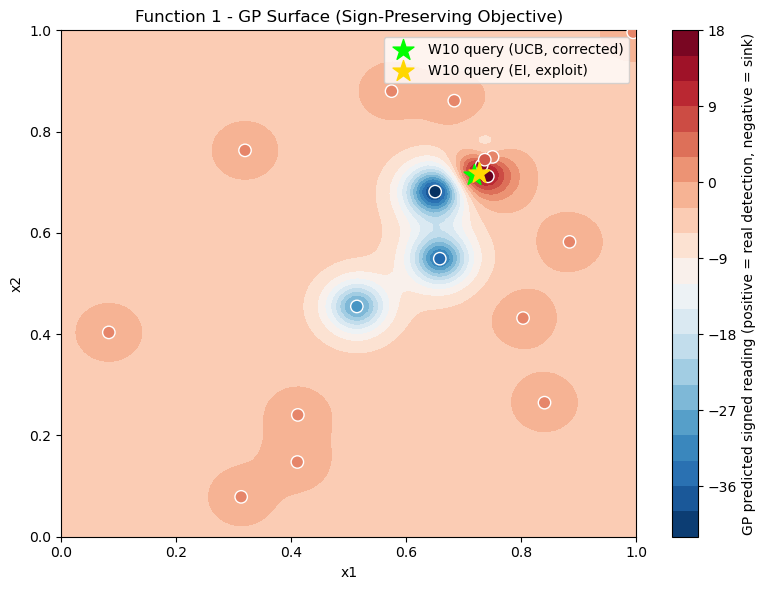

In [9]:
# Visualize the GP's predicted surface over a fine grid, overlaying the observed points 
# (colored by signed reading) and both candidate queries (UCB vs EI).

grid_n = 100
x1_grid = np.linspace(0, 1, grid_n)
x2_grid = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])

mu_grid, _ = gp_F1.predict(grid_points, return_std=True)
mu_grid = mu_grid.reshape(grid_n, grid_n)

plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, mu_grid, levels=20, cmap='RdBu_r')
plt.colorbar(label='GP predicted signed reading (positive = real detection, negative = sink)')
plt.scatter(all_inputs_F1[:, 0], all_inputs_F1[:, 1], c=signed_readings,
            edgecolors='white', s=80, cmap='RdBu_r', zorder=5)
plt.scatter(query_F1[0], query_F1[1], marker='*', c='lime', s=250, zorder=10, label='W10 query (UCB, corrected)')
plt.scatter(query_ei_F1[0], query_ei_F1[1], marker='*', c='gold', s=250, zorder=10, label='W10 query (EI, exploit)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Function 1 - GP Surface (Sign-Preserving Objective)')
plt.legend()
plt.tight_layout()
plt.show()

### Alternative option for Function 1

In [10]:
log_readings = np.log10(np.abs(all_outputs_F1) + 1e-300)

sorted_logs = np.sort(log_readings)[::-1]
gaps = sorted_logs[:-1] - sorted_logs[1:]
largest_gap_idx = np.argmax(gaps)
floor = (sorted_logs[largest_gap_idx] + sorted_logs[largest_gap_idx + 1]) / 2

print(f"Largest gap: {sorted_logs[largest_gap_idx]:.1f} to {sorted_logs[largest_gap_idx + 1]:.1f}")
print(f"Floor set at: {floor:.1f}")

log_readings = np.log10(np.abs(all_outputs_F1) + 1e-300) 
 
new_eps = 1e-300
signed_scoreA = np.arcsinh(all_outputs_F1 / new_eps)

best_detection_idx = np.argmax(signed_scoreA)

print(f"Best point: {all_outputs_F1[best_detection_idx]:.6e} at {all_inputs_F1[best_detection_idx]}")
print(f"Strongest detection: {all_outputs_F1[best_detection_idx]:.6e} at {all_inputs_F1[best_detection_idx]}")
print(f"  log reading: {log_readings[best_detection_idx]:.1f}")
print(f"Log reading range: {log_readings.min():.1f} to {log_readings.max():.1f}") 

print(f"\nAll points (sorted by detection strength):")
sort_idxA = np.argsort(log_readings)[::-1]
for i in sort_idxA:
    print(f"  {all_inputs_F1[i]} --> output: {all_outputs_F1[i]:.3e} --> log reading: {log_readings[i]:.1f}")

Largest gap: -123.5 to -187.3
Floor set at: -155.4
Best point: 6.880000e-15 at [0.741762 0.711733]
Strongest detection: 6.880000e-15 at [0.741762 0.711733]
  log reading: -14.2
Log reading range: -187.3 to -2.4

All points (sorted by detection strength):
  [0.65011406 0.68152635] --> output: -3.606e-03 --> log reading: -2.4
  [0.658199 0.549042] --> output: -7.450e-06 --> log reading: -5.1
  [0.513943 0.454749] --> output: -3.890e-08 --> log reading: -7.4
  [0.741762 0.711733] --> output: 6.880e-15 --> log reading: -14.2
  [0.73102363 0.73299988] --> output: 7.711e-16 --> log reading: -15.1
  [0.736438 0.74455 ] --> output: 2.010e-19 --> log reading: -18.7
  [0.75 0.75] --> output: 1.330e-22 --> log reading: -21.9
  [0.411304 0.240532] --> output: 8.070e-24 --> log reading: -23.1
  [0.68341817 0.86105746] --> output: 2.535e-40 --> log reading: -39.6
  [0.57432921 0.8798981 ] --> output: 1.033e-46 --> log reading: -46.0
  [0.88388983 0.58225397] --> output: 6.230e-48 --> log reading: -4

In [11]:
source1_points = np.array([
    [0.731024, 0.733000],  # Initial best
    [0.736438, 0.744550],  # W8 return and close to initial
    [0.741762, 0.711733],  # W9 return and above initial best
])
pairsA = [(0,1),(0,2),(1,2)]
dists = [np.linalg.norm(source1_points[i] - source1_points[j]) for i,j in pairsA]
new_ls = np.mean(dists) * 1.5  
print(f"Length scale: {new_ls:.3f}")

Length scale: 0.035


In [12]:
# GP
kernel_F1a = Matern(nu=2.5, length_scale=new_ls, length_scale_bounds="fixed")
gp_F1a = GaussianProcessRegressor(kernel=kernel_F1a, n_restarts_optimizer=10, normalize_y=True)
gp_F1a.fit(all_inputs_F1, signed_scoreA)

np.random.seed(42)
candidates_F1a = np.random.uniform(0, 1, (50000, 2))
mu_F1a, sigma_F1a = gp_F1a.predict(candidates_F1a, return_std=True)

best_so_far_F1a = signed_scoreA.max()
ei_F1a = compute_ei(mu_F1a, sigma_F1a, best_so_far_F1a, xi=0.5)   # consider rescaling xi

best_idx_F1a = np.argmax(ei_F1a)
query_F1a = candidates_F1a[best_idx_F1a]

print(f"\nWeek 10 Query (Test): {format_query(query_F1a)}")
print(f"mu (log reading): {mu_F1a[best_idx_F1a]:.2f}, sigma: {sigma_F1a[best_idx_F1a]:.2f}, EI: {ei_F1a[best_idx_F1a]:.4f}")

# Week 10 Query (Test) results as 0.766846-0.723665 with mu (log reading): 589.37, sigma: 353.23, EI: 108.6805
# Current best is 0.741762, 0.711733 and second best is 0.731024, 0.733000. 
# Week 10 Query (repeat W9 method): 0.718356-0.714455 - this is used for submission 
#       because rather than expanding value to 0.76, narrowing down to 0.71 is sensible exploitation.


Week 10 Query (Test): 0.766846-0.723665
mu (log reading): 589.37, sigma: 353.23, EI: 108.6805


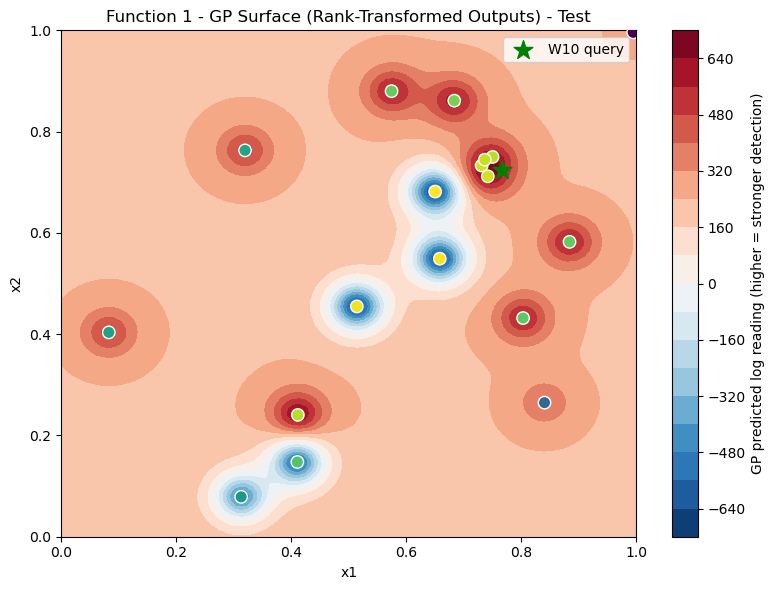

In [13]:
grid_n = 100
x1_grid = np.linspace(0, 1, grid_n)
x2_grid = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])
 
mu_grid, _ = gp_F1a.predict(grid_points, return_std=True)
mu_grid = mu_grid.reshape(grid_n, grid_n)
 
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, mu_grid, levels=20, cmap='RdBu_r')
plt.colorbar(label='GP predicted log reading (higher = stronger detection)')
plt.scatter(all_inputs_F1[:, 0], all_inputs_F1[:, 1], c=log_readings,
            edgecolors='white', s=80, cmap='viridis', zorder=5)
plt.scatter(query_F1a[0], query_F1a[1], marker='*', c='green', s=200, zorder=10, label='W10 query')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Function 1 - GP Surface (Rank-Transformed Outputs) - Test')
plt.legend()
plt.tight_layout()
plt.show()

# Function 2, Noisy Log-Likelihood, 2D array, 10 original samples - Week 10

In [14]:
# =============================================================================
# Function 2, Noisy Log-Likelihood, 2D array, 10 original samples
# =============================================================================
# Previous weeks
# W3: Same GP + EI + distance-maximisation pipeline as F1.
# W4: GP (Matérn + WhiteKernel noise) + Thompson sampling
# W5: Random Forest regression; greedy argmax of predicted mean over 50,000 random candidates
# W6: Random Forest (500 trees, depth 3); Thompson sampling (per-tree)
# W7: Random Forest: Max depth = 3; UCB κ = 1.5; full-ensemble UCB, improving uncertainty estimation
# W8: Anisotropic GP (PDP-derived length-scale bounds from RF) + UCB (κ = 0.1)
# W9: GP with Random Forest-informed kernel parameters 
#     Adaptive kernel length scales learned from Random Forest partial dependence

# change: Extend domain boundaries and apply multi-start optimisation on posterior means 
#         to maximise immediate gains, though it risks narrowing search trajectories.

print("\n" + "=" * 60)
print("Function 2 - Week 10")
print("=" * 60)

f2_inputs = np.load('initial_data/function_2/initial_inputs.npy')
f2_outputs = np.load('initial_data/function_2/initial_outputs.npy')

prev_queries_2 = np.array([
    [1.053349, 0.934354],               # W2
    [0.660188, 0.32993],                # W3
    [0.729589, 0.938148],               # W4
    [0.685444, 0.332456],               # W5 (above initial max)
    [0.684233, 0.440152],               # W6
    [0.692436, 0.991256],               # W7
    [0.700034, 0.148684],               # W8 (so far the best, above initial max)
    [0.708298, 0.004444],               # W9 (above initial max)
])
prev_outputs_2 = np.array([-0.040652,          # W2 (worst result)
                           0.468742,           # W3 (fail)
                           0.487563,           # W4 (fail)
                           0.646548,           # W5 (above initial max)
                           0.578337,           # W6 (fail)
                           0.563546,           # W7 (fail)
                           0.683188,           # W8 (so far the best, above initial max)
                           0.636073,           # W9 (above initial max)
                          ])

all_inputs_F2  = np.vstack([f2_inputs, prev_queries_2])
all_outputs_F2 = np.hstack([f2_outputs, prev_outputs_2])

best_idx_original = np.argmax(all_outputs_F2)
print(f"Training points: {len(all_outputs_F2)}")
print(f"Observed best output: {all_outputs_F2[best_idx_original]:.6f}")
print(f"Observed best query:  {all_inputs_F2[best_idx_original]}")


Function 2 - Week 10
Training points: 18
Observed best output: 0.683188
Observed best query:  [0.700034 0.148684]


In [15]:
kernel_F2 = (
    ConstantKernel(1.0, (1e-2, 1e2))
    * Matern(
        length_scale=[0.3, 0.3],
        length_scale_bounds=[(0.03, 3.0), (0.03, 3.0)],
        nu=2.5,
    )
    + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-6, 1.0))
)

gp_F2 = GaussianProcessRegressor(
    kernel=kernel_F2,
    n_restarts_optimizer=50,
    normalize_y=True,
    random_state=0,
)
gp_F2.fit(all_inputs_F2, all_outputs_F2)

print("Learned kernel:")
print(gp_F2.kernel_)


Learned kernel:
1.06**2 * Matern(length_scale=[0.079, 3], nu=2.5) + WhiteKernel(noise_level=0.00981)


In [16]:
# Pure-exploitation search over an *extended* domain (upper bound pushed from 1.0 to 1.2):
# draw 100k random candidates, seed local L-BFGS-B refinements of the GP posterior mean from
# the top 30 candidates by predicted mean, and keep only solutions far enough 
# from any previously queried point (distance > MIN_DISTANCE).

DOMAIN_LO = np.array([0.0, 0.0])
DOMAIN_HI = np.array([1.2, 1.2])
MIN_DISTANCE = 0.01   # A choice made to test valid point as valid = search_dist > MIN_DISTANCE

rng = np.random.default_rng(42)
search_F2 = rng.uniform(DOMAIN_LO, DOMAIN_HI, size=(100000, 2))

search_dist = cdist(search_F2, all_inputs_F2).min(axis=1)
valid = search_dist > MIN_DISTANCE  # hence, MIN_DISTANCE = 0.01 is defined
search_F2 = search_F2[valid]
search_dist = search_dist[valid]

search_mu, search_sd = gp_F2.predict(search_F2, return_std=True)
top_n = 30
seed_idx = np.argsort(search_mu)[-top_n:][::-1]

def objective(point):
    point = np.asarray(point, dtype=float).reshape(1, -1)
    return -gp_F2.predict(point)[0]

solutions = []
for idx in seed_idx:
    result = minimize(
        objective,
        x0=search_F2[idx],
        bounds=list(zip(DOMAIN_LO, DOMAIN_HI)),
        method="L-BFGS-B",
    )
    point = result.x
    distance = np.min(np.linalg.norm(all_inputs_F2 - point, axis=1))
    if distance >= MIN_DISTANCE:
        mean, std = gp_F2.predict(point.reshape(1, -1), return_std=True)
        solutions.append((float(mean[0]), float(std[0]), float(distance), point))

solutions.sort(key=lambda item: item[0], reverse=True)

mean_F2, std_F2, dist_F2, query_F2 = solutions[0]

print("W10 query (posterior-mean maximisation):")
print(f"  query = {query_F2}")
print(f"  GP mean = {mean_F2:.6f}")
print(f"  GP std  = {std_F2:.6f}")
print(f"  nearest previous point = {dist_F2:.6f}")

W10 query (posterior-mean maximisation):
  query = [0.69745364 0.        ]
  GP mean = 0.668211
  GP std  = 0.032231
  nearest previous point = 0.011720


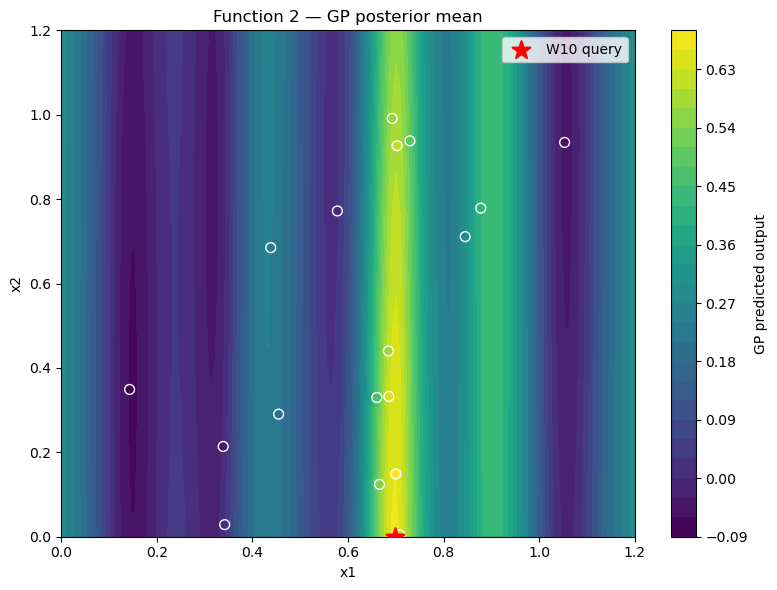

In [17]:
# Visualise the GP posterior mean over the extended domain as a filled contour, 
# overlaying the observed points and the posterior-mean-maximising W10 query.

grid_n = 150
x1 = np.linspace(DOMAIN_LO[0], DOMAIN_HI[0], grid_n)
x2 = np.linspace(DOMAIN_LO[1], DOMAIN_HI[1], grid_n)
X1, X2 = np.meshgrid(x1, x2)
grid = np.column_stack([X1.ravel(), X2.ravel()])

mean_grid = gp_F2.predict(grid).reshape(grid_n, grid_n)

plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, mean_grid, levels=25)
plt.colorbar(label="GP predicted output")
plt.scatter(all_inputs_F2[:, 0], all_inputs_F2[:, 1], c=all_outputs_F2, edgecolors="white", s=50, zorder=4)

plt.scatter(
    query_F2[0], query_F2[1],
    marker="*", s=180, linewidths=1.5, zorder=6, color = 'red',
    label="W10 query",
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Function 2 — GP posterior mean")
plt.legend()
plt.tight_layout()
plt.show()

### Local GP search is tested for comparison, not for submission

In [18]:
# Locally re-optimise the GP posterior mean in a small neighbourhood 
# around a hand-picked TARGET point, using bounded L-BFGS-B restricted to that neighbourhood.

TARGET = np.array([0.70, 0.1])

# Search only in a small neighbourhood around the target
LOCAL_LO = np.array([0.68, 0.08])
LOCAL_HI = np.array([0.72, 0.12])

def objective(point):
    point = np.asarray(point).reshape(1, -1)
    return -gp_F2.predict(point)[0]

result = minimize(
    objective,
    x0=TARGET,
    bounds=list(zip(LOCAL_LO, LOCAL_HI)),
    method="L-BFGS-B",
)

query_F2a = result.x

mean_F2a, std_F2a = gp_F2.predict(
    query_F2a.reshape(1, -1),
    return_std=True
)

dist_F2a = np.min(
    np.linalg.norm(all_inputs_F2 - query_F2a, axis=1)
)

print("Local query:")
print(" query =", query_F2a)
print(" GP mean =", mean_F2a[0])
print(" GP std =", std_F2a[0])
print(" nearest previous point =", dist_F2a)

Local query:
 query = [0.69776772 0.08      ]
 GP mean = 0.664827626293584
 GP std = 0.03090945729922249
 nearest previous point = 0.05436217508457289


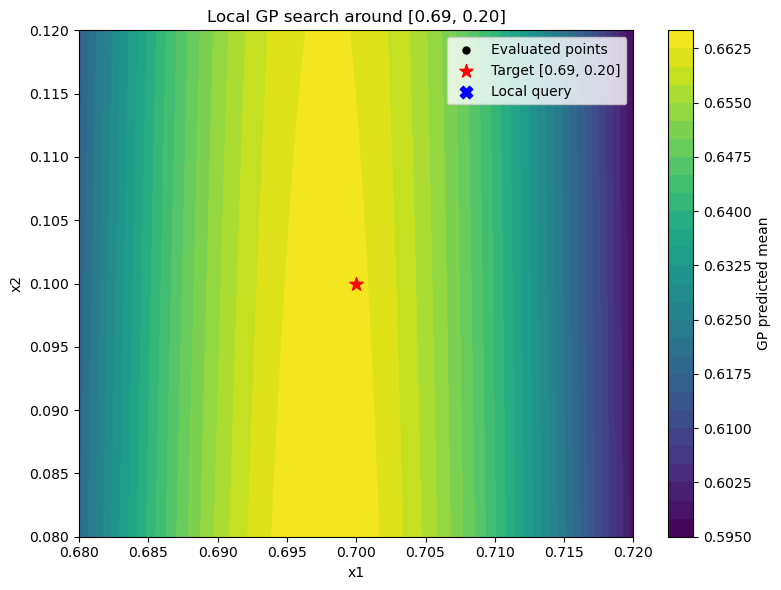

In [19]:
# -------------------------------------------------
# Local region around the target
# -------------------------------------------------
TARGET = np.array([0.70, 0.10])

LOCAL_LO = np.array([0.68, 0.08])
LOCAL_HI = np.array([0.72, 0.12])

# Grid for local plotting
x1 = np.linspace(LOCAL_LO[0], LOCAL_HI[0], 200)
x2 = np.linspace(LOCAL_LO[1], LOCAL_HI[1], 200)

X1, X2 = np.meshgrid(x1, x2)

grid = np.column_stack([
    X1.ravel(),
    X2.ravel()
])

# GP prediction
mu, sigma = gp_F2.predict(grid, return_std=True)

MU = mu.reshape(X1.shape)

# -------------------------------------------------
# Plot GP mean
# -------------------------------------------------
plt.figure(figsize=(8, 6))

contour = plt.contourf(
    X1,
    X2,
    MU,
    levels=30
)

plt.colorbar(contour, label="GP predicted mean")

# Existing evaluated points
plt.scatter(
    all_inputs_F2[:, 0],
    all_inputs_F2[:, 1],
    c="black",
    s=25,
    label="Evaluated points"
)

# Target [0.69, 0.20]
plt.scatter(
    TARGET[0],
    TARGET[1],
    c="red",
    s=100,
    marker="*",
    label="Target [0.69, 0.20]"
)

# Your selected local optimum, if you calculated one
plt.scatter(
    query_F2[0],
    query_F2[1],
    c="blue",
    s=80,
    marker="X",
    label="Local query"
)

# Local boundaries
plt.xlim(LOCAL_LO[0], LOCAL_HI[0])
plt.ylim(LOCAL_LO[1], LOCAL_HI[1])

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Local GP search around [0.69, 0.20]")
plt.legend()
plt.tight_layout()
plt.show()

# Function 3, A drug discovery project, 3D array, 15 original samples - Week 10

In [20]:
# =============================================================================
# Function 3, A drug discovery project, 3D array, 15 original samples
# =============================================================================
# Previous weeks
# W3: Explicitly mixes exploration (random candidates), local exploitation (perturbations near the best point), 
#     and hypothesis-driven exploitation (directed candidates).
# W4: GP EI (ξ = 0.001, exploitation-biased) blended 50/50 with quadratic polynomial surrogate
# W5: Random Forest trained on degree-2 polynomial features; argmax over 10,000 global candidates
# W6: ExtraTrees (200 trees); Degree-2 polynomial interactions; Argmax over RF predictions
# W7: ExtraTrees + polynomial features; max_features: None vs. sqrt
# W8: ExtraTrees (WLS-weighted, polynomial features) + LCB (κ = 0.5) with exclusion filter
# W9: ExtraTrees surrogate with polynomial feature expansion; Ensemble disagreement and nonlinear feature interactions

# change: Fit polynomial ExtraTrees on log-transformed targets for lower confidence bound optimisation, 
#         though the transform relies on strictly negative target values.

print("\n" + "=" * 60)
print("Function 3 - Week 10")
print("=" * 60)

f3_inputs = np.load('initial_data/function_3/initial_inputs.npy')
f3_outputs = np.load('initial_data/function_3/initial_outputs.npy')

prev_queries_F3 = np.array([
    [0.540087, 0.652622, 0.079307],              # W2
    [0.378956, 0.302768, 0.459346],              # W3
    [0.375610, 0.057061, 0.589980],              # W4
    [0.378956, 0.302768, 0.459346],              # W5
    [0.378956, 0.302768, 0.459346],              # W6 (it was same as W5)
    [0.494932, 0.994690, 0.457121],              # W7
    [0.398479, 0.316913, 0.467387],              # W8
    [0.321464, 0.375442, 0.524156],              # W9
])
prev_outputs_F3 = np.array([
    -0.050615,               # W2 (fail)
    -0.019508,               # W3 (above initial max)
    -0.119425,               # W4  (fail)
    -0.021357,               # W5 (above initial max)
    -0.015072,               # W6 (above initial max, current best)
    -0.069598,               # W7 (fail)
    -0.023447,               # W8 (above initial max)
    -0.029269,               # W9 (above initial max)
])

X = np.vstack([f3_inputs, prev_queries_F3])
Y = np.hstack([f3_outputs, prev_outputs_F3])

print(f"Total points: {len(Y)}, best (max): {Y.max():.6f}")


Function 3 - Week 10
Total points: 23, best (max): -0.015072


In [21]:
# Log-transform the (all-negative) output as log(-Y) so a tree model trains on a better- behaved scale, 
# and build degree-2 polynomial interaction features from the 3 raw inputs.
# NOTE: this transform will break if Y >= 0 for any point -- assumed but not yet validated here.

eps = 1e-10
Y_log = np.log(-Y + eps)

# --- Polynomial features ---
poly   = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = ['A', 'B', 'C', 'A*B', 'A*C', 'B*C', 'A^2', 'B^2', 'C^2']

In [22]:
# Fit an ExtraTrees regressor on the polynomial features against the log-transformed target,
# print feature importances, then invert the transform to compare training predictions 
# with the original (un-transformed) outputs.

rf_F3 = ExtraTreesRegressor(n_estimators=200, max_features='sqrt', min_samples_leaf=2, random_state=42)
rf_F3.fit(X_poly, Y_log)

print("\nRF feature importances:")
for name, imp in zip(feature_names, rf_F3.feature_importances_):
    print(f"  {name:6s}: {imp:.4f}")

train_preds_log = rf_F3.predict(X_poly)
train_preds = -(np.exp(train_preds_log) - eps)
print(f"\nRF train R2 (original space): {r2_score(Y, train_preds):.4f}")
print(f"RF train predictions vs actual:")
for pred, actual in zip(train_preds, Y):
    print(f"  predicted: {pred:.6f}, actual: {actual:.6f}")


RF feature importances:
  A     : 0.1039
  B     : 0.0726
  C     : 0.2260
  A*B   : 0.0704
  A*C   : 0.0691
  B*C   : 0.0762
  A^2   : 0.0469
  B^2   : 0.1134
  C^2   : 0.2215

RF train R2 (original space): 0.5296
RF train predictions vs actual:
  predicted: -0.090842, actual: -0.112122
  predicted: -0.082234, actual: -0.087963
  predicted: -0.092009, actual: -0.111415
  predicted: -0.051725, actual: -0.034835
  predicted: -0.058009, actual: -0.048008
  predicted: -0.083852, actual: -0.110621
  predicted: -0.161562, actual: -0.398926
  predicted: -0.130036, actual: -0.113869
  predicted: -0.098576, actual: -0.131461
  predicted: -0.088110, actual: -0.094190
  predicted: -0.057162, actual: -0.046947
  predicted: -0.081219, actual: -0.105965
  predicted: -0.111842, actual: -0.118048
  predicted: -0.052424, actual: -0.036378
  predicted: -0.071942, actual: -0.056758
  predicted: -0.052151, actual: -0.050615
  predicted: -0.025811, actual: -0.019508
  predicted: -0.065784, actual: -0.119

In [23]:
# Generate 50,000 random 3D candidates, drop any too close to an already-evaluated point,
# then collect per-tree predictions from the ExtraTrees ensemble 
# so their spread can serve as an uncertainty estimate (mean and std across trees).

np.random.seed(42)
candidates_F3 = np.random.uniform(0, 1, (50000, 3))
cand_poly  = poly.transform(candidates_F3)

min_distance = 0.001
distances = np.min(np.linalg.norm(candidates_F3[:, None, :] - X[None, :, :], axis=2), axis=1)
mask = distances > min_distance
candidates_F3 = candidates_F3[mask]
cand_poly = poly.transform(candidates_F3)

tree_preds = np.array([tree.predict(cand_poly) for tree in rf_F3.estimators_])
mean_preds = tree_preds.mean(axis=0)
std_preds  = tree_preds.std(axis=0)

In [24]:
# Acquisition: Lower Confidence Bound in log-space 
# (mean - kappa*std; argmin because the GP models log(-Y) with -Y minimised). 
# Report the top 10 candidates and the chosen query,
# converting predictions back to the original output scale for interpretation.

kappa_F3 = 0.3
acquisition = mean_preds - kappa_F3 * std_preds
best_idx_F3    = np.argmin(acquisition)
query_F3       = candidates_F3[best_idx_F3]

top_n = 10
top_indices = np.argsort(acquisition)[:top_n]
print(f"\nTop {top_n} candidates (LCB, kappa={kappa_F3}, log space):")
for i, idx in enumerate(top_indices):
    pred_original = -(np.exp(mean_preds[idx]) - eps)
    print(f"  {i+1}: {format_query(candidates_F3[idx])}, "
          f"mean(log): {mean_preds[idx]:.4f}, std(log): {std_preds[idx]:.4f}, "
          f"acq: {acquisition[idx]:.4f}, pred(original): {pred_original:.6f}")

print(f"\nWeek 10 Query: {format_query(query_F3)}")
pred_original = -(np.exp(mean_preds[best_idx_F3]) - eps)
print(f"Predicted (original space): {pred_original:.6f}")


Top 10 candidates (LCB, kappa=0.3, log space):
  1: 0.371804-0.301322-0.451223, mean(log): -3.5871, std(log): 0.3683, acq: -3.6976, pred(original): -0.027677
  2: 0.391640-0.287350-0.454695, mean(log): -3.5756, std(log): 0.3857, acq: -3.6913, pred(original): -0.027999
  3: 0.395514-0.311838-0.461924, mean(log): -3.5977, std(log): 0.3035, acq: -3.6888, pred(original): -0.027386
  4: 0.416781-0.293153-0.451687, mean(log): -3.5486, std(log): 0.4019, acq: -3.6692, pred(original): -0.028765
  5: 0.407193-0.319669-0.463244, mean(log): -3.5634, std(log): 0.3163, acq: -3.6583, pred(original): -0.028342
  6: 0.386270-0.294080-0.486489, mean(log): -3.5252, std(log): 0.4096, acq: -3.6480, pred(original): -0.029447
  7: 0.410236-0.317621-0.438427, mean(log): -3.5259, std(log): 0.3937, acq: -3.6440, pred(original): -0.029426
  8: 0.416191-0.319155-0.445957, mean(log): -3.5291, std(log): 0.3804, acq: -3.6432, pred(original): -0.029333
  9: 0.415185-0.307609-0.426270, mean(log): -3.5037, std(log): 0

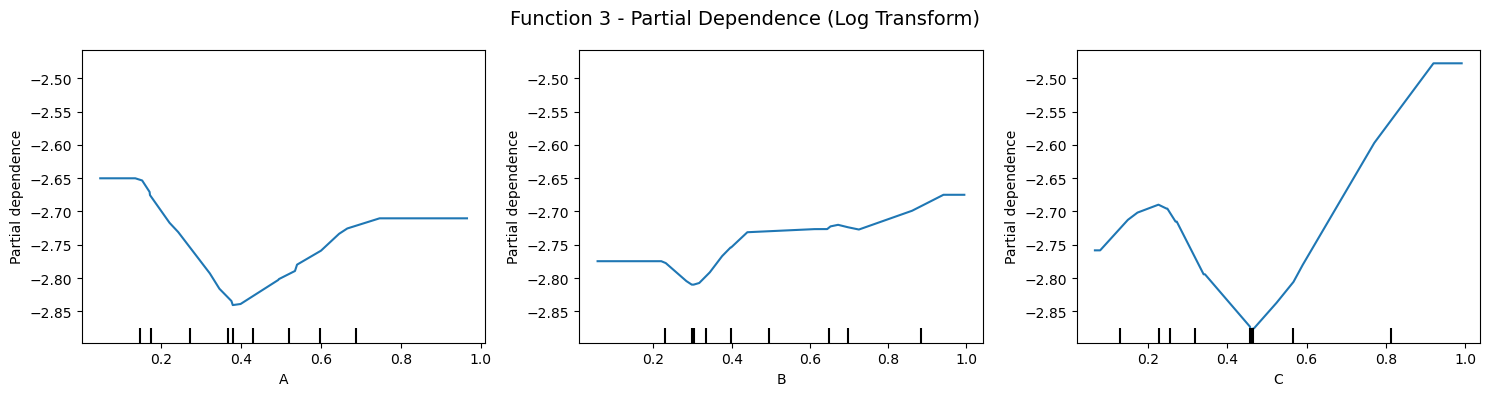

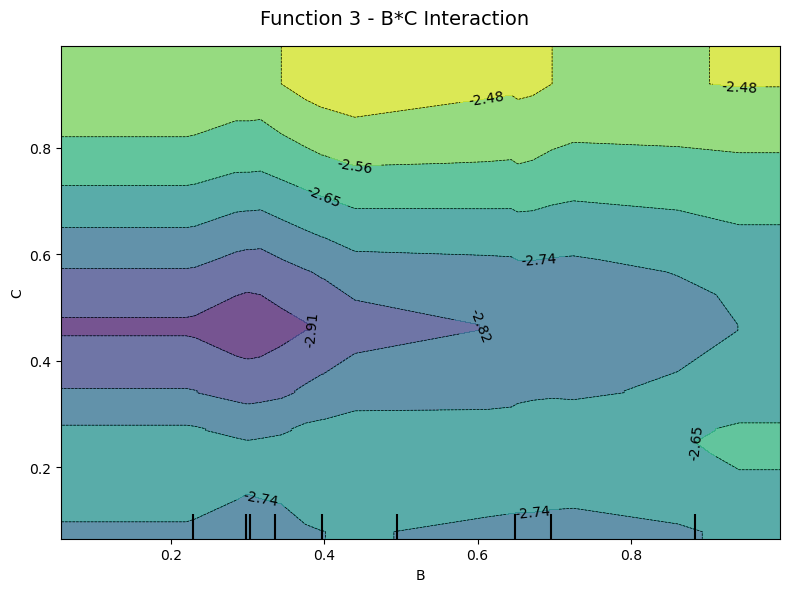

In [25]:
# Fit a second ExtraTrees model directly on the raw (non-polynomial) inputs, 
# purely so the partial dependence plots are interpretable, 
# then plot 1D PDPs per input and the B*C interaction.

rf_raw = ExtraTreesRegressor(n_estimators=200, max_features='sqrt', min_samples_leaf=2, random_state=42)
rf_raw.fit(X, Y_log)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(rf_raw, X, features=[0, 1, 2],
                                         feature_names=['A', 'B', 'C'], ax=axes)
plt.suptitle('Function 3 - Partial Dependence (Log Transform)', fontsize=14)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(rf_raw, X, features=[(1, 2)],
                                         feature_names=['A', 'B', 'C'], ax=[ax2])
plt.suptitle('Function 3 - B*C Interaction', fontsize=14)
plt.tight_layout()
plt.show()

In [26]:
# Compare three candidate output transforms (none / sqrt / log) via 
# leave-one-out cross- validation: for each transform, 
# refit the polynomial+ExtraTrees pipeline while holding out each point in turn, 
# invert the transform, and report overall and top-5 MAE plus rank overlap
# to see which transform predicts the best points most reliably.
# NOTE: this validation is being run only now, after log(-Y) was already used above.

n = len(Y)
eps = 1e-10

top5_indices = np.argsort(Y)[::-1][:5]
print("Top 5 points (closest to zero):")
for i, idx in enumerate(top5_indices):
    print(f"  {i+1}: index {idx}, Y = {Y[idx]:.7f}")

transforms = [
    ("none",  lambda y: y,                lambda p: p),
    ("sqrt",  lambda y: -np.sqrt(-y),     lambda p: -(p**2)),
    ("log",   lambda y: np.log(-y + eps), lambda p: -(np.exp(p) - eps)),
]

for t_name, forward, inverse in transforms:
    Y_t = forward(Y)
    preds_original = np.zeros(n)

    for i in range(n):
        X_train = np.delete(X, i, axis=0)
        Y_train = np.delete(Y_t, i, axis=0)
        X_test  = X[i:i+1]

        poly_cv = PolynomialFeatures(degree=2, include_bias=False)
        X_train_poly = poly_cv.fit_transform(X_train)
        X_test_poly  = poly_cv.transform(X_test)

        rf_cv = ExtraTreesRegressor(
            n_estimators=200, max_features='sqrt',
            min_samples_leaf=2, random_state=42
        )
        rf_cv.fit(X_train_poly, Y_train)

        pred_t = rf_cv.predict(X_test_poly)[0]
        preds_original[i] = inverse(pred_t)

    mae = mean_absolute_error(Y, preds_original)
    top5_mae = mean_absolute_error(Y[top5_indices], preds_original[top5_indices])
    pred_top5 = np.argsort(preds_original)[::-1][:5]
    rank_overlap = len(set(top5_indices) & set(pred_top5))

    print(f"\nTransform: {t_name}")
    print(f"  Overall MAE: {mae:.6f}")
    print(f"  Top-5 MAE:   {top5_mae:.6f}")
    print(f"  Top-5 rank overlap: {rank_overlap}/5")
    print(f"  Top-5 detail:")
    for idx in top5_indices:
        print(f"    idx {idx:2d}: actual {Y[idx]:.7f} -> pred {preds_original[idx]:.7f} (err {abs(Y[idx]-preds_original[idx]):.7f})")

Top 5 points (closest to zero):
  1: index 19, Y = -0.0150720
  2: index 16, Y = -0.0195080
  3: index 18, Y = -0.0213570
  4: index 21, Y = -0.0234470
  5: index 22, Y = -0.0292690

Transform: none
  Overall MAE: 0.042113
  Top-5 MAE:   0.021520
  Top-5 rank overlap: 4/5
  Top-5 detail:
    idx 19: actual -0.0150720 -> pred -0.0357662 (err 0.0206942)
    idx 16: actual -0.0195080 -> pred -0.0347259 (err 0.0152179)
    idx 18: actual -0.0213570 -> pred -0.0342397 (err 0.0128827)
    idx 21: actual -0.0234470 -> pred -0.0407769 (err 0.0173299)
    idx 22: actual -0.0292690 -> pred -0.0707454 (err 0.0414764)

Transform: sqrt
  Overall MAE: 0.039714
  Top-5 MAE:   0.015674
  Top-5 rank overlap: 4/5
  Top-5 detail:
    idx 19: actual -0.0150720 -> pred -0.0321351 (err 0.0170631)
    idx 16: actual -0.0195080 -> pred -0.0306346 (err 0.0111266)
    idx 18: actual -0.0213570 -> pred -0.0299606 (err 0.0086036)
    idx 21: actual -0.0234470 -> pred -0.0347676 (err 0.0113206)
    idx 22: actual 

# Function 4, Warehouse business, 4D array, 30 original samples - Week 10

In [27]:
# =============================================================================
# Function 4, Warehouse business, 4D array, 30 original samples
# =============================================================================
# Previous weeks
# W3: Exploration-oriented due to relatively high (UCB, κ = 2.0) over 10k uniformly random candidates.
# W4: GP (Matérn) + Thompson sampling
# W5: RF surrogate; uncertainty estimated from tree-to-tree disagreement (rf_predict_with_std); 
#     acquisition = EI (ξ = 0.01) over Latin Hypercube candidates
# W6: SVM classifier (gate) + ARD GP (refine); Threshold-based binary labelling; EI
# W7: SVM gate + GP (EI); SVM probability threshold; Increased GP α to smooth noisy responses and added global; added global LHS
# W8: GP (Matérn, selected over RF using LOO R²) + UCB (κ = 0.5)
# W9: GP with extensive diagnostic visualisations; Human interpretation of response surfaces guides subsequent exploration

# change: Select candidates greedily based on GP predicted means to exploit high-performing local neighbourhoods, 
#         forfeiting exploration of unvisited regions.
 
print("\n" + "=" * 60)
print("Function 4 - Week 10")
print("=" * 60)

f4_inputs  = np.load('initial_data/function_4/initial_inputs.npy')
f4_outputs = np.load('initial_data/function_4/initial_outputs.npy')

prev_queries_F4 = np.array([
    [0.149845, 0.155724, 0.461280, 0.344491],              # W2
    [0.330258, 0.414348, 0.433728, 0.411341],              # W3
    [0.424125, 0.404716, 0.487507, 0.367688],              # W4
    [0.424125, 0.404716, 0.487507, 0.367688],              # W5 so it was the same as Week 4
    [0.255396, 0.450674, 0.468413, 0.490566],              # W6
    [0.371614, 0.422247, 0.370132, 0.421911],              # W7 
    [0.378911, 0.420065, 0.360647, 0.355610],              # W8
    [0.431137, 0.410316, 0.341871, 0.422095],              # W9
])
prev_outputs_F4 = np.array([-7.13212,          # W2 fail
                            0.20379,           # W3 (above initial max)
                            -0.99160,          # W4 (above initial max)
                            -0.99147,          # W5 (above initial max)
                            -3.142015,         # W6 (above initial max)
                            0.657358,          # W7 (above initial max, second best)
                            0.664078,          # W8 (above initial max, so far the best)
                            0.47213,           # W9 (above initial max)
                           ]) 

all_inputs_F4  = np.vstack([f4_inputs, prev_queries_F4])
all_outputs_F4 = np.hstack([f4_outputs, prev_outputs_F4])

best_idx = np.argmax(all_outputs_F4)
best_point_so_far = all_inputs_F4[best_idx]
best_val_so_far = all_outputs_F4[best_idx]
print(f"Total points: {len(all_outputs_F4)}, best (max) so far: "
      f"{best_val_so_far:.4f} at {format_query(best_point_so_far)}")


Function 4 - Week 10
Total points: 38, best (max) so far: 0.6641 at 0.378911-0.420065-0.360647-0.355610


In [28]:
# Build a mixed candidate pool for the GP: Gaussian perturbations around the W7 query,
# perturbations around the W8 query, and a small globally-random set -- 
# biasing search toward the two most recent promising neighbourhoods rather than the full domain.

np.random.seed(42)

week7_query = np.array([0.371614, 0.422247, 0.370132, 0.421911])
week8_query = np.array([0.378911, 0.420065, 0.360647, 0.355610])  

candidates_w7 = np.array([np.clip(week7_query + np.random.normal(0, 0.08, 4), 0, 1) for _ in range(5000)])
candidates_w8 = np.array([np.clip(week8_query + np.random.normal(0, 0.08, 4), 0, 1) for _ in range(3000)])
candidates_global = np.random.uniform(0, 1, size=(2000, 4))

candidates_F4 = np.vstack([candidates_w7, candidates_w8, candidates_global])
print(f"\nCandidates: {len(candidates_w7)} W7 + {len(candidates_w8)} W8 + {len(candidates_global)} global = {len(candidates_F4)} total")


Candidates: 5000 W7 + 3000 W8 + 2000 global = 10000 total


In [29]:
# Fit a GP (Matern kernel, fixed length-scale) on all observed Function 4 points.

kernel_F4 = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=0.4,
    length_scale_bounds='fixed',
    nu=2.5
)
gp_F4 = GaussianProcessRegressor(kernel=kernel_F4, n_restarts_optimizer=20, alpha=1e-4, normalize_y=True)
gp_F4.fit(all_inputs_F4, all_outputs_F4)

print(f"Fitted kernel: {gp_F4.kernel_}")
print(f"Log-marginal-likelihood: {gp_F4.log_marginal_likelihood_value_:.4f}")

Fitted kernel: 0.772**2 * Matern(length_scale=0.4, nu=2.5)
Log-marginal-likelihood: -17.3164


In [30]:
# Compute Expected Improvement over the candidate pool for reference, 
# but the query # actually selected below is argmax(mu_F4) -- 
# the GP posterior *mean* -- not argmax(EI).
# EI is calculated and printed but is not the criterion used to choose the query 
# (see markdown note below on the resulting trail).

mu_F4, sigma_F4 = gp_F4.predict(candidates_F4, return_std=True)

xi = 0.01
best_f = all_outputs_F4.max()
improvement = mu_F4 - best_f - xi
Z_F4 = np.where(sigma_F4 > 1e-10, improvement / sigma_F4, 0.0)
ei_F4 = np.where(sigma_F4 > 1e-10,
              improvement * norm.cdf(Z_F4) + sigma_F4 * norm.pdf(Z_F4),
              0.0)

best_index_F4 = np.argmax(mu_F4)  # See (ei_F4) results below
query_F4 = candidates_F4[best_index_F4]

print(f"\nWeek 10 Query: {format_query(query_F4)}")
print(f"mean: {mu_F4[best_index_F4]:.3f}")
print(f"std:  {sigma_F4[best_index_F4]:.3f}")
print(f"EI:   {ei_F4[best_index_F4]:.6f}")

w2_mu, w2_std = gp_F4.predict(week7_query.reshape(1, -1), return_std=True)
q_mu, q_std = gp_F4.predict(query_F4.reshape(1, -1), return_std=True)
print(f"W2 point:  mean={w2_mu[0]:.3f}  std={w2_std[0]:.3f}")
print(f"W10 query: mean={q_mu[0]:.3f}  std={q_std[0]:.3f}") 


Week 10 Query: 0.372317-0.403232-0.376261-0.380970
mean: 0.814
std:  0.273
EI:   0.192815
W2 point:  mean=0.663  std=0.089
W10 query: mean=0.814  std=0.273


| **Key Comparison Attribute** | `np.argmax(mu)` | `np.argmax(ei)` |
|------------------------------|-----------------|-----------------|
| **Strategy** | Pure Exploitation | Expected Improvement |
| **Uses Variance ($\sigma$)?** | ❌ No | ✅ Yes |
| **Trade-off Mechanism** | None (100% greedy) | Adaptive (higher reward potential **or** higher uncertainty increases score) |
| **Exploration Trigger** | Never explores unseen regions if local mean is high | Explores high-variance areas if potential payoff exceeds current best |
| **When to Use** | At final deployment (choosing the final best parameter recommendation) | During optimization iterations (searching for optimal hyperparameters) |

if best_index_F4 = np.argmax(**ei_F4**), this gives  

- Week 10 Query: 0.423642-0.495705-0.380218-0.393410
- mean: 0.067; std:  1.311; EI:   0.274539
- W2 point:  mean=0.663  std=0.089
- W10 query: mean=0.067  std=1.311

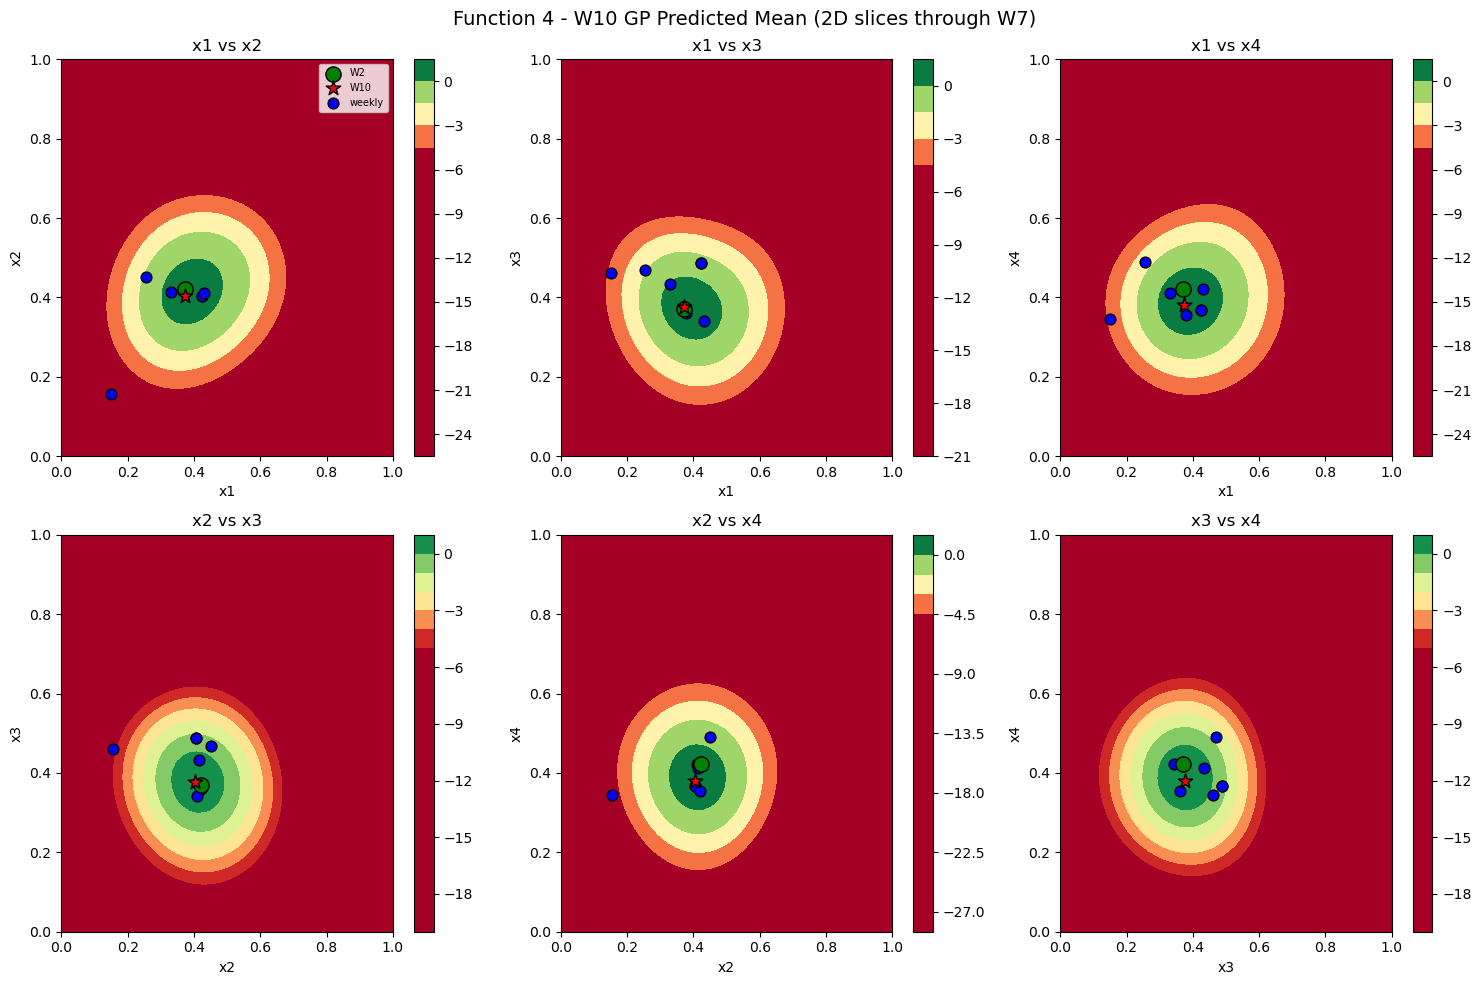

In [31]:
# 2D GP predicted mean -- sweep pairs of dimensions through W2
dim_names = ['x1', 'x2', 'x3', 'x4']
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (d1, d2) in enumerate(pairs):
    ax = axes[idx]
    res = 50
    v1 = np.linspace(0, 1, res)
    v2 = np.linspace(0, 1, res)
    grid = np.tile(week7_query, (res * res, 1))
    g1, g2 = np.meshgrid(v1, v2)
    grid[:, d1] = g1.ravel()
    grid[:, d2] = g2.ravel()

    pred = gp_F4.predict(grid).reshape(res, res)
    contour = ax.contourf(v1, v2, pred, levels=20, cmap='RdYlGn', vmin=-5, vmax=1)
    plt.colorbar(contour, ax=ax)

    ax.scatter(week7_query[d1], week7_query[d2], c='green', edgecolors='black', s=120, zorder=5, label='W2')
    ax.scatter(query_F4[d1], query_F4[d2], c='red', edgecolors='black', s=120, zorder=5, marker='*', label='W10')
    ax.scatter(prev_queries_F4[:, d1], prev_queries_F4[:, d2], c='blue', edgecolors='black', s=60, zorder=4, label='weekly')

    ax.set_xlabel(dim_names[d1])
    ax.set_ylabel(dim_names[d2])
    ax.set_title(f'{dim_names[d1]} vs {dim_names[d2]}')

axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - W10 GP Predicted Mean (2D slices through W7)', fontsize=14)
plt.tight_layout()
plt.show()


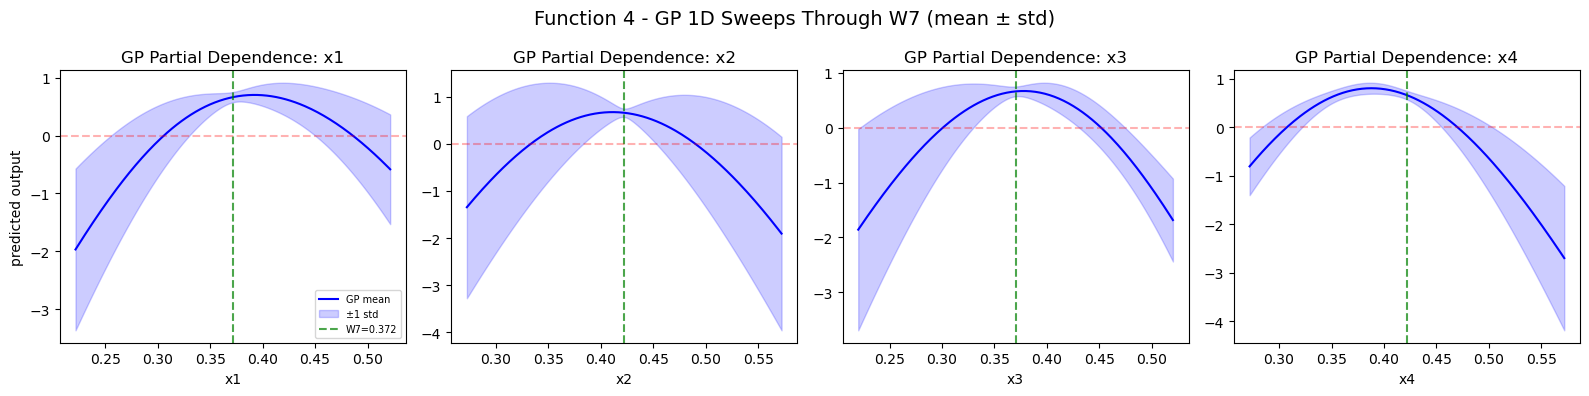

In [32]:
# RF 1D partial dependence through W7 -- shows basin shape per dimension
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    sweep = np.linspace(week7_query[i] - 0.15, week7_query[i] + 0.15, 200)    
    test_points = np.tile(week7_query, (200, 1))
    test_points[:, i] = sweep

    sweep_mu, sweep_std = gp_F4.predict(test_points, return_std=True)

    ax.plot(sweep, sweep_mu, 'b-', label='GP mean')
    ax.fill_between(sweep, sweep_mu - sweep_std, sweep_mu + sweep_std, alpha=0.2, color='blue', label='±1 std')
    ax.axvline(x=week7_query[i], color='green', linestyle='--', alpha=0.7, label=f'W7={week7_query[i]:.3f}')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    ax.set_xlabel(dim_names[i])
    ax.set_ylabel('predicted output' if i == 0 else '')
    ax.set_title(f'GP Partial Dependence: {dim_names[i]}')
axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - GP 1D Sweeps Through W7 (mean ± std)', fontsize=14)
plt.tight_layout()
plt.show()

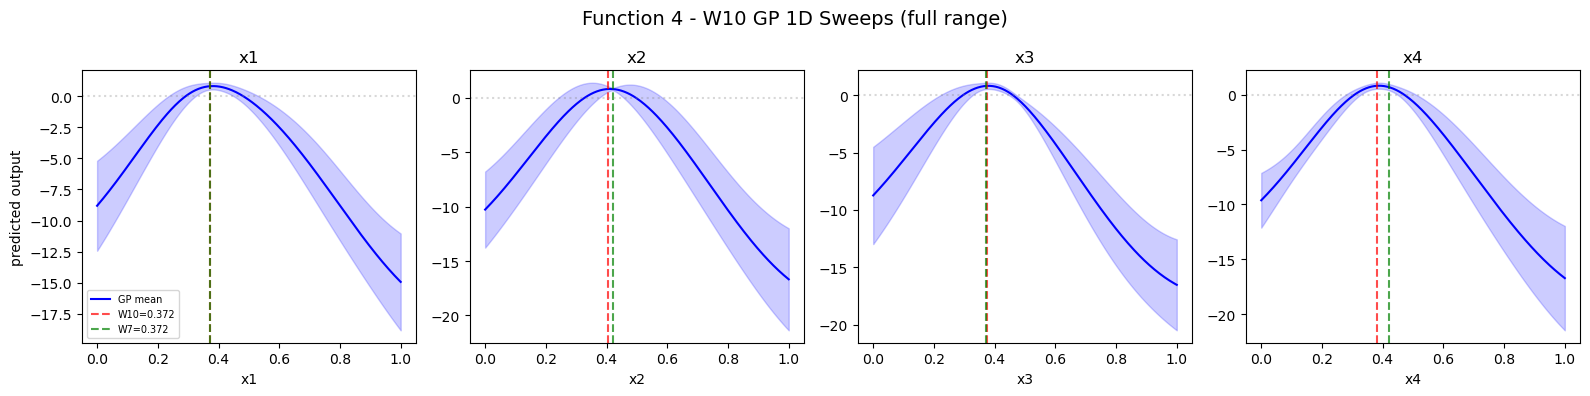

In [33]:
# 1D sweeps with W10 GP
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
dim_names = ['x1', 'x2', 'x3', 'x4']

for i, ax in enumerate(axes):
    sweep = np.linspace(0.0, 1.0, 300)
    test_points = np.tile(query_F4, (300, 1))  # sweep through the W10 query point
    test_points[:, i] = sweep

    sweep_mu, sweep_std = gp_F4.predict(test_points, return_std=True)

    ax.plot(sweep, sweep_mu, 'b-', label='GP mean')
    ax.fill_between(sweep, sweep_mu - sweep_std, sweep_mu + sweep_std, alpha=0.2, color='blue')
    ax.axvline(x=query_F4[i], color='red', linestyle='--', alpha=0.7, label=f'W10={query_F4[i]:.3f}')
    ax.axvline(x=week7_query[i], color='green', linestyle='--', alpha=0.7, label=f'W7={week7_query[i]:.3f}')
    ax.axhline(y=0, color='grey', linestyle=':', alpha=0.3)
    ax.set_xlabel(dim_names[i])
    ax.set_ylabel('predicted output' if i == 0 else '')
    ax.set_title(f'{dim_names[i]}')
axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - W10 GP 1D Sweeps (full range)', fontsize=14)
plt.tight_layout()
plt.show()

# Function 5, A chemical process in a factory, 4D array, 20 original samples - Week 10

In [34]:
# =============================================================================
# Function 5, A chemical process in a factory, 4D array, 20 original samples
# =============================================================================
# Previous weeks
# W3: Strong exploitation
#     SVR ranks a locally generated candidate pool (local perturbations and directional moves around the incumbent). 
# W4: Linear regression (search direction) → SVR pre-filter → GP EI (ξ = 0.005)
# W5: Two-stage approach: SVR pre-filters candidates (top 3,000 retained), 
#     then GP (log-transformed outputs, Matérn kernel) evaluates them using EI (ξ = 0.005)
# W6: SVR + GP (log space); Log transform of output; EI
# W7: SVR filter + GP (EI); SVR candidate pool = 3000; EI ξ = 0.005; improving search coverage
# W8: SVR pre-filter (top 3000 candidates) → GP (log-transformed outputs) + EI (ξ = 0.005)
# W9: GP with constrained local and boundary search; Boundary pinning and structured perturbations alter search dynamics

# change: Use an SVR candidate pre-filter and select the max predicted log-mean to ensure safe, 
#         conservative updates when pushing into unobserved input domains.
 
print("\n" + "=" * 60)
print("Function 5 - Week 10")
print("=" * 60)

f5_inputs  = np.load('initial_data/function_5/initial_inputs.npy')
f5_outputs = np.load('initial_data/function_5/initial_outputs.npy')

prev_queries_F5 = np.array([
    [0.417098, 0.756030, 0.129487, 1.149173],               # W2 (above initial max)
    [0.386633, 0.821843, 0.127990, 0.999900],               # W3
    [0.269378, 0.810637, 0.999999, 0.999999],               # W4 (above initial max)
    [0.366671, 0.879874, 0.999999, 0.996800],               # W5 (above initial max)
    [0.495228, 0.809693, 0.999999, 0.999990],               # W6 (above initial max)
    [0.382122, 0.995456, 0.999999, 0.999999],               # W7 (above initial max)
    [0.566703, 0.999727, 0.999999, 0.999999],               # W8 (above initial max)
    [0.626657, 0.999999, 0.999999, 0.999999],               # W9 (best)
])
prev_outputs_F5 = np.array([1829.809875,                    # W2 (above initial max)
                            710.602251,                     # W3 (fail)
                            2699.104490,                    # W4 (above initial max)
                            3179.389393,                    # W5 (above initial max)
                            2855.140103,                    # W6 (above initial max)
                            4461.243621,                    # W7 (above initial max)
                            4826.282687,                    # W8 (above initial max) 
                            5022.767511,                    # W9 (best)
                           ])

all_inputs_F5  = np.vstack([f5_inputs, prev_queries_F5])
all_outputs_F5 = np.hstack([f5_outputs, prev_outputs_F5])

print(f"Total points: {len(all_outputs_F5)}, best (max): {all_outputs_F5.max():.2f}")


Function 5 - Week 10
Total points: 28, best (max): 5022.77


In [35]:
# Scale inputs/outputs and fit an SVR surrogate. 
# Used later as a fast pre-filter over the candidate pool and
# as a cross-check against the GP's predictions.

input_scaler  = StandardScaler()
output_scaler = StandardScaler()
X_scaled = input_scaler.fit_transform(all_inputs_F5)
Y_scaled = output_scaler.fit_transform(all_outputs_F5.reshape(-1, 1)).ravel()
 
svr_F5 = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.01)
svr_F5.fit(X_scaled, Y_scaled) 

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.01
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [36]:
# Fit a GP (Matern kernel) on log1p-transformed outputs -- 
# the main surrogate used for acquisition below.
y_log     = np.log1p(all_outputs_F5)
kernel_gp = ConstantKernel(1.0, (0.001, 1000)) * Matern(length_scale=0.2, nu=2.5)
gp_F5      = GaussianProcessRegressor(kernel=kernel_gp, n_restarts_optimizer=25, normalize_y=True)
gp_F5.fit(all_inputs_F5, y_log)

,kernel,"1**2 * Matern...e=0.2, nu=2.5)"
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,25
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,"Matern(length...e=0.2, nu=2.5)"
,kernel__k1__constant_value,1.0


In [37]:
# Build a candidate pool around the current best point: local Gaussian perturbations 
# plus a 'directed' set that is deliberately pushed further out along each dimension 
# (up to 2.0, beyond the original [0,1] domain -- no data exists there yet). 
# Use the SVR to pre-filter down to the most promising in-bounds candidates before handing off to the GP.

best_point_F5 = all_inputs_F5[np.argmax(all_outputs_F5)]
np.random.seed(42)
 
local = []
for _ in range(6000):
    c = best_point_F5 + np.random.normal(0, 0.03, 4)
    c = np.clip(c, 0, 2.0) 
    local.append(c)
 
directed = []
for _ in range(4000):
    c = best_point_F5.copy()
    c[0] = np.clip(c[0] + abs(np.random.normal(0, 0.2)), 0, 2.0)
    c[1] = np.clip(c[1] + abs(np.random.normal(0, 0.1)), 0, 2.0)
    c[2] = np.clip(c[2] + abs(np.random.normal(0, 0.05)), 0, 2.0)
    c[3] = np.clip(c[3] + abs(np.random.normal(0, 0.05)), 0, 2.0)
    directed.append(c)
 
candidates_F5 = np.vstack([local, directed])

X_cand_scaled = input_scaler.transform(candidates_F5)
svr_preds_s   = svr_F5.predict(X_cand_scaled)
svr_preds     = output_scaler.inverse_transform(svr_preds_s.reshape(-1, 1)).ravel()

above_bounds = (candidates_F5 > 1.0).any(axis=1)
in_bounds    = ~above_bounds

top_idx_ib   = np.argsort(svr_preds[in_bounds])[-5000:]
filtered_ib  = candidates_F5[in_bounds][top_idx_ib]

filtered = np.vstack([candidates_F5[above_bounds], filtered_ib])

print(f"Above-bounds candidates passed to GP: {above_bounds.sum()}")
print(f"In-bounds candidates passed to GP: {len(filtered_ib)}")

Above-bounds candidates passed to GP: 9230
In-bounds candidates passed to GP: 770


In [38]:
# best_indx from mu_log
# --- acquisition function EI replaced with GP argmax to test out of [0,1] bounds
# GP predict on filtered candidates

mu_log, sigma_log = gp_F5.predict(filtered, return_std=True)
best_idx_F5 = np.argmax(mu_log)
query_F5 = filtered[best_idx_F5]

# The GP prediction that is printed is still mu_log, not the UCB score.
# So the chosen point is: high (mean + uncertainty)
 
print(f"\nWeek 10 Query (from mu_log, safe exploiting for submission):       {format_query(query_F5)}")
print(f"GP predicted yield: {np.expm1(mu_log[best_idx_F5]):.2f}")
print(f"GP std (log scale): {sigma_log[best_idx_F5]:.4f}")
svr_at_query = output_scaler.inverse_transform(
    svr_F5.predict(input_scaler.transform(query_F5.reshape(1, -1))).reshape(-1, 1)
).ravel()[0]
print(f"SVR prediction:     {svr_at_query:.2f}")


Week 10 Query (from mu_log, safe exploiting for submission):       0.656411-1.185597-1.026548-1.160768
GP predicted yield: 10800.73
GP std (log scale): 0.8879
SVR prediction:     5982.17


`np.argmax(mu_log)` is used for submission

| Feature | `np.argmax(mu_log)` | `np.argmax(ucb)` |
|---------|----------------------|------------------|
| **Strategy** | Greedy (Exploitation only) | Upper Confidence Bound (Exploration + Exploitation) |
| **Exploration** | Zero (will miss optimal paths if initial estimates are bad) | Structured (explores arms with high variance or low sample counts) |
| **Use Case** | Final deployment when training/exploration is finished | Active learning, online decision-making, Multi-Armed Bandits |

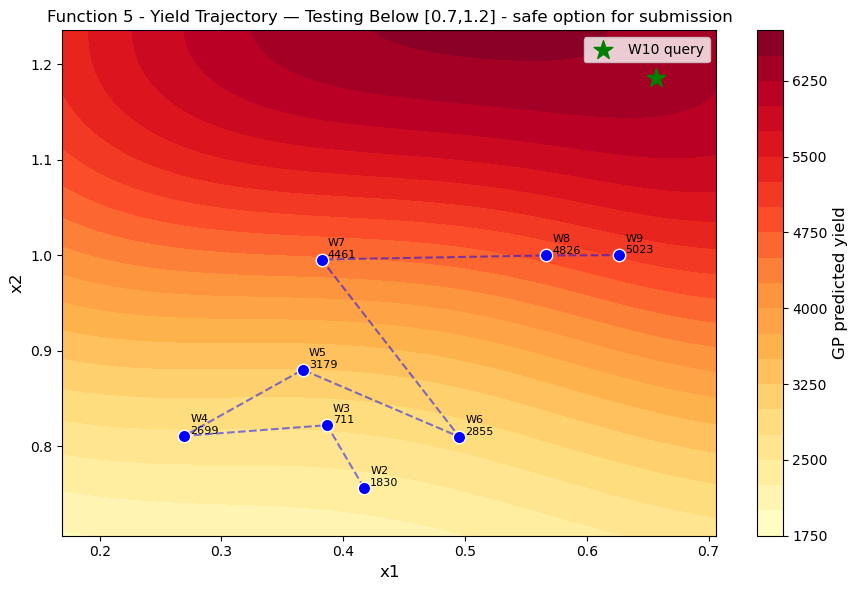

In [39]:
# --- Plot: Contour with extended bounds --- Consider best_idx_F5a = np.argmax(mu_log)
pad = 0.05
x1_min = min(prev_queries_F5[:, 0].min(), query_F5[0]) - 0.1
x1_max = max(prev_queries_F5[:, 0].max(), query_F5[0]) + pad
x2_min = min(prev_queries_F5[:, 1].min(), query_F5[1]) - pad
x2_max = max(prev_queries_F5[:, 1].max(), query_F5[1]) + pad

grid_n = 80
x1_range = np.linspace(x1_min, x1_max, grid_n)
x2_range = np.linspace(x2_min, x2_max, grid_n)
X1_g, X2_g = np.meshgrid(x1_range, x2_range)

grid_4d = np.column_stack([X1_g.ravel(), X2_g.ravel(),
                           np.full(grid_n**2, 0.999999),
                           np.full(grid_n**2, 0.999999)])
mu_grid = np.expm1(gp_F5.predict(grid_4d))
mu_grid = mu_grid.reshape(grid_n, grid_n)

fig, ax = plt.subplots(figsize=(9, 6))
cf = ax.contourf(X1_g, X2_g, mu_grid, levels=20, cmap='YlOrRd')
cbar = fig.colorbar(cf)
cbar.set_label('GP predicted yield', fontsize=12)

for i in range(len(prev_queries_F5)):
    ax.scatter(prev_queries_F5[i, 0], prev_queries_F5[i, 1], c='blue',
               edgecolors='white', s=80, zorder=5)
    ax.annotate(f'W{i+2}\n{prev_outputs_F5[i]:.0f}',
                (prev_queries_F5[i, 0] + 0.005, prev_queries_F5[i, 1] + 0.002), fontsize=8)
ax.plot(prev_queries_F5[:, 0], prev_queries_F5[:, 1], 'b--', alpha=0.5, zorder=4)
ax.scatter(query_F5[0], query_F5[1], marker='*', c='green', s=200, zorder=10, label='W10 query')

ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_title('Function 5 - Yield Trajectory — Testing Below [0.7,1.2] - safe option for submission')
ax.legend()
fig.tight_layout()
plt.show()

In [40]:
# Sanity-check both surrogates: compare GP vs SVR predictions against 
# the actual observed outputs at each historical query, 
# then probe how the GP extrapolates for x1 values beyond the originally trained domain (> 1.0).

print("\n--- GP vs SVR at historical queries ---")
print(f"{'Week':<6} {'Actual':>10} {'GP pred':>10} {'SVR pred':>10}")
for i, (q, actual) in enumerate(zip(prev_queries_F5, prev_outputs_F5)):
    gp_pred  = np.expm1(gp_F5.predict(q.reshape(1, -1))[0])
    svr_pred = output_scaler.inverse_transform(
        svr_F5.predict(input_scaler.transform(q.reshape(1, -1))).reshape(-1, 1)
    ).ravel()[0]
    print(f"W{i+1:<5} {actual:>10.1f} {gp_pred:>10.1f} {svr_pred:>10.1f}")

# --- GP extrapolation check (new this week) ---
print("\n--- GP extrapolation beyond 1.0 ---")
print(f"{'x1':>6} {'GP yield':>10} {'GP std':>10}")
for x1_val in [0.95, 1.0, 1.05, 1.1, 1.2, 1.3, 1.5]:
    test = np.array([[x1_val, 0.999999, 0.999999, 0.999999]])
    mu, sig = gp_F5.predict(test, return_std=True)
    print(f"{x1_val:>6.2f} {np.expm1(mu[0]):>10.1f} {sig[0]:>10.4f}")


--- GP vs SVR at historical queries ---
Week       Actual    GP pred   SVR pred
W1         1829.8     1829.8     1814.5
W2          710.6      710.6      726.8
W3         2699.1     2699.1     2683.0
W4         3179.4     3179.4     3195.4
W5         2855.1     2855.1     2838.7
W6         4461.2     4461.2     4444.8
W7         4826.3     4826.3     4842.1
W8         5022.8     5022.8     5006.7

--- GP extrapolation beyond 1.0 ---
    x1   GP yield     GP std
  0.95     4161.7     0.8004
  1.00     3757.9     0.9819
  1.05     3346.1     1.1638
  1.10     2946.5     1.3426
  1.20     2234.3     1.6814
  1.30     1671.5     1.9845
  1.50      951.9     2.4656


### Test for ucb in best_inx (not use in submission)
**best_idx_F5a = np.argmax(ucb_F5a)**

In [41]:
# Score the SVR-filtered candidates with the GP (log space) and pick the next query via
# Upper Confidence Bound (kappa=2.5), then cross-check the chosen point's SVR prediction.
# Tested results only - not use for submission

mu_log, sigma_log = gp_F5.predict(filtered, return_std=True)
ucb_F5a = mu_log + 2.5 * sigma_log   
best_idx_F5a = np.argmax(ucb_F5a) 
query_F5a = filtered[best_idx_F5a]

print(f"\nWeek 10 Query from ucb (deliberately sacrifices some predicted mean, not for submission) : {format_query(query_F5a)}")
print(f"GP predicted yield (GP mean): {np.expm1(mu_log[best_idx_F5a]):.2f}")
print(f"GP std (log scale): {sigma_log[best_idx_F5a]:.4f}")
print(f"UCB score:          {ucb_F5a[best_idx_F5a]:.4f}")
svr_at_query = output_scaler.inverse_transform(
    svr_F5.predict(input_scaler.transform(query_F5a.reshape(1, -1))).reshape(-1, 1)
).ravel()[0]
print(f"SVR prediction:     {svr_at_query:.2f}")


Week 10 Query from ucb (deliberately sacrifices some predicted mean, not for submission) : 1.316266-1.143359-1.092614-1.072311
GP predicted yield (GP mean): 2082.95
GP std (log scale): 2.1518
UCB score:          13.0216
SVR prediction:     2386.49


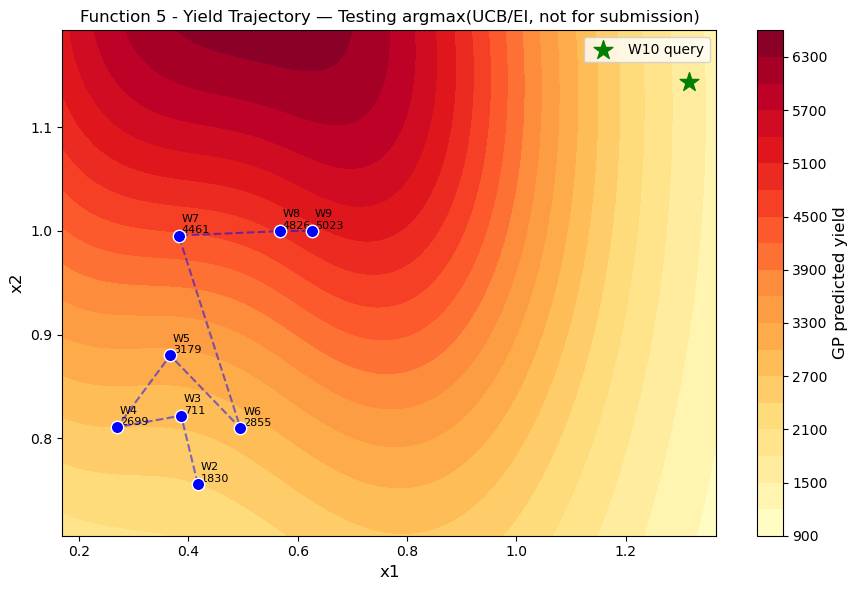

In [42]:
# Plot a 2D contour (x1 vs x2, with x3/x4 held near 1) of the GP's predicted yield,
#  overlaying the historical query trajectory and the UCB-selected W10 query 
#  to visualise the search path as it moves beyond the original [0,1] bounds.

pad = 0.05
x1_min = min(prev_queries_F5[:, 0].min(), query_F5a[0]) - 0.1
x1_max = max(prev_queries_F5[:, 0].max(), query_F5a[0]) + pad
x2_min = min(prev_queries_F5[:, 1].min(), query_F5a[1]) - pad
x2_max = max(prev_queries_F5[:, 1].max(), query_F5a[1]) + pad

grid_n = 80
x1_range = np.linspace(x1_min, x1_max, grid_n)
x2_range = np.linspace(x2_min, x2_max, grid_n)
X1_g, X2_g = np.meshgrid(x1_range, x2_range)

grid_4d = np.column_stack([X1_g.ravel(), X2_g.ravel(),
                           np.full(grid_n**2, 0.999999),
                           np.full(grid_n**2, 0.999999)])
mu_grid = np.expm1(gp_F5.predict(grid_4d))
mu_grid = mu_grid.reshape(grid_n, grid_n)

fig, ax = plt.subplots(figsize=(9, 6))
cf = ax.contourf(X1_g, X2_g, mu_grid, levels=20, cmap='YlOrRd')
cbar = fig.colorbar(cf)
cbar.set_label('GP predicted yield', fontsize=12)

for i in range(len(prev_queries_F5)):
    ax.scatter(prev_queries_F5[i, 0], prev_queries_F5[i, 1], c='blue',
               edgecolors='white', s=80, zorder=5)
    ax.annotate(f'W{i+2}\n{prev_outputs_F5[i]:.0f}',
                (prev_queries_F5[i, 0] + 0.005, prev_queries_F5[i, 1] + 0.002), fontsize=8)
ax.plot(prev_queries_F5[:, 0], prev_queries_F5[:, 1], 'b--', alpha=0.5, zorder=4)
ax.scatter(query_F5a[0], query_F5a[1], marker='*', c='green', s=200, zorder=10, label='W10 query')

ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_title('Function 5 - Yield Trajectory — Testing argmax(UCB/EI, not for submission)')
ax.legend()
fig.tight_layout()
plt.show()

# Function 6 A cake recipe, 5D array, 20 original samples - Week 10

In [43]:
# =============================================================================
# Function 6 A cake recipe, 5D array, 20 original samples
# =============================================================================
# Previous weeks
# W3: ARD GP + EI (ξ = 0.05) over a mixed candidate pool consisting of uniform random samples, 
#     Latin Hypercube Sampling (LHS), and perturbations around the top five recipes.
# W4: GP with ARD Matérn + EI (ξ = 0.02)
# W5: RF surrogate (200 trees); acquisition via Thompson sampling 
#     using a single randomly selected decision tree rather than the ensemble mean
# W6: Random Forest (500 trees); Maximin LHS candidate design; Full-ensemble UCB
# W7: Random Forest Max depth = 5 (new); UCB κ = 1.5; the first explicit regularisation of the RF model
# W8: Hybrid GP + RF (inverse-RMSE weighted blend) + EI with multi-restart L-BFGS-B optimization
# W9: Random Forest surrogate with SHAP explainability; Feature importance explanations influence future search direction

# change: Combine global and local LHS scored by an isotropic GP to refine candidate selection within a complex 5D space.

print("\n" + "=" * 60)
print("Function 6 - Week 10")
print("=" * 60)

f6_inputs  = np.load('initial_data/function_6/initial_inputs.npy')
f6_outputs = np.load('initial_data/function_6/initial_outputs.npy')

prev_queries_F6 = np.array([
    [0.939456, 0.643603, 0.531941, 1.031640, 0.012391],              # W2
    [0.463219, 0.306404, 0.635240, 0.999844, 0.015672],              # W3 
    [0.344063, 0.007363, 0.627449, 0.999999, 0.004891],              # W4
    [0.611853, 0.139494, 0.292145, 0.366362, 0.456070],              # W5
    [0.362372, 0.287752, 0.659391, 0.946547, 0.011897],              # W6 
    [0.119239, 0.206322, 0.998767, 0.816254, 0.063518],              # W7 
    [0.471908, 0.343816, 1.000000, 0.988610, 0.154640],              # W8 
    [0.471060, 0.378037, 0.568185, 0.870856, 0.026973],              # W9 
])
prev_outputs_F6 = np.array([-1.241946,         # W2 (fail)
                            -0.352945,         # W3 (above initial best)
                            -0.837300,         # W4 (fail)
                            -1.468430,         # W5 (fail)
                            -0.454581,         # W6 (above initial best)
                            -0.859304,         # W7 (fail)
                            -0.650775,         # W8 (above initial best)
                            -0.338381,         # W9 (above initial best, so far the best)
                           ])

all_inputs_F6  = np.vstack([f6_inputs, prev_queries_F6])
all_outputs_F6 = np.hstack([f6_outputs, prev_outputs_F6])

print(f"Total observations: {all_inputs_F6.shape[0]}, best (max): {all_outputs_F6.max():.4f}")


Function 6 - Week 10
Total observations: 28, best (max): -0.3384


In [44]:
# Fit an SVR pipeline (with input scaling) as a secondary surrogate/interpretability model,
# and set up a Latin Hypercube sampler (maximin criterion) for candidate generation below.
# SVR is fitted for plotting and review, not used in the acquisition step 

svr_F6 = Pipeline([('scl', StandardScaler()), ('svr', SVR(kernel='rbf', C=50, gamma=0.1, epsilon=0.001))])
svr_F6.fit(all_inputs_F6, all_outputs_F6)

space      = Space([(0.0, 1.0)] * 5)
lhs        = Lhs(criterion="maximin", iterations=100)

In [45]:
# Fit the main GP surrogate for Function 6, and (re-)set up the LHS sampler 
# used for the two-stage candidate search that follows.

kernel = 1.0 * Matern(length_scale=1.0, nu=2.5)
gp_F6 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True, random_state=42)
gp_F6.fit(all_inputs_F6, all_outputs_F6)

# --- Two-stage candidate refinement ---
space = Space([(0.0, 1.0)] * 5)
lhs = Lhs(criterion="maximin", iterations=100)

In [46]:
# Stage 1: global LHS
np.random.seed(42)
stage1 = np.array(lhs.generate(space.dimensions, 5000))
mu_1, std_1 = gp_F6.predict(stage1, return_std=True)
stage1_scores = compute_ucb(mu_1, std_1, kappa=2.5)

# Stage 2: local refinement around top-K UCB scores from stage 1
top_k = 50
top_k_idx = np.argsort(stage1_scores)[-top_k:]
top_k_points = stage1[top_k_idx]

radius = 0.05
stage2 = []
for point in top_k_points:
    local = point + np.random.uniform(-radius, radius, size=(100, 5))
    local = np.clip(local, 0, 1)
    stage2.append(local)
stage2 = np.vstack(stage2)

# Combine and score all candidates using UCB
all_candidates = np.vstack([stage1, stage2])
mu_all, std_all = gp_F6.predict(all_candidates, return_std=True)
all_scores = compute_ucb(mu_all, std_all, kappa=2.5)

best_index_F6 = np.argmax(all_scores)
query_F6 = all_candidates[best_index_F6]

# Report source
source = "Stage 1 (global)" if best_index_F6 < len(stage1) else "Stage 2 (refined)"

print(f"\nStage 1: {len(stage1)} global candidates")
print(f"Stage 2: {len(stage2)} local candidates ({top_k} anchors × 100 each, radius={radius})")
print(f"Total:   {len(all_candidates)} candidates")

print(f"\nWeek 10 Query (GP + UCB): {format_query(query_F6)}")
print(f"  Predicted UCB value: {all_scores[best_index_F6]:.4f}")
print(f"  Source: {source}")


Stage 1: 5000 global candidates
Stage 2: 5000 local candidates (50 anchors × 100 each, radius=0.05)
Total:   10000 candidates

Week 10 Query (GP + UCB): 0.317166-0.547049-0.105786-1.000000-0.002390
  Predicted UCB value: 0.2269
  Source: Stage 2 (refined)


  0%|          | 0/28 [00:00<?, ?it/s]

C:\Users\mayzu\AppData\Local\Temp\ipykernel_16916\1939028743.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, all_inputs_F6,


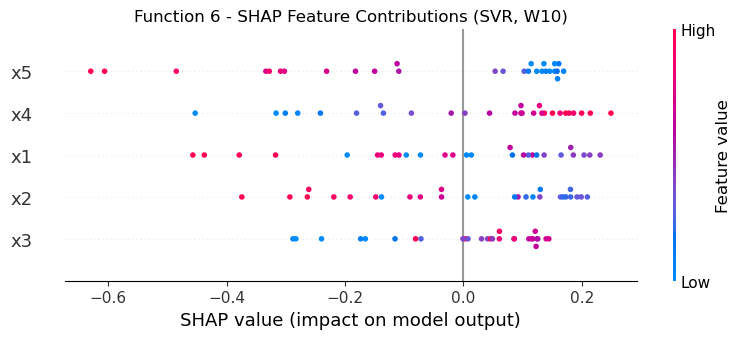

In [47]:
# --- Interpretability: SHAP on SVR (actual surrogate) ---
np.random.seed(42)
background  = all_inputs_F6[np.random.choice(len(all_inputs_F6), size=20, replace=False)]
explainer   = shap.KernelExplainer(svr_F6.predict, background)
shap_values = explainer.shap_values(all_inputs_F6, nsamples=100)

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, all_inputs_F6,
                  feature_names=[f'x{i+1}' for i in range(5)], show=False)
plt.title('Function 6 - SHAP Feature Contributions (SVR, W10)')
plt.tight_layout()
plt.show()

  0%|          | 0/28 [00:00<?, ?it/s]

C:\Users\mayzu\AppData\Local\Temp\ipykernel_16916\3414386157.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, all_inputs_F6,


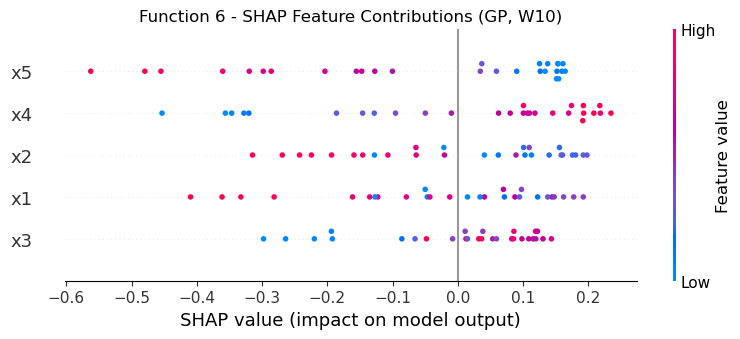

In [48]:
# --- Interpretability: SHAP on SVR (actual surrogate) ---
np.random.seed(42)
background  = all_inputs_F6[np.random.choice(len(all_inputs_F6), size=20, replace=False)]
explainer   = shap.KernelExplainer(gp_F6.predict, background)
shap_values = explainer.shap_values(all_inputs_F6, nsamples=100)

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, all_inputs_F6,
                  feature_names=[f'x{i+1}' for i in range(5)], show=False)
plt.title('Function 6 - SHAP Feature Contributions (GP, W10)')
plt.tight_layout()
plt.show()

# Function 7, Unspecified field, 6D array, 30 original samples - Week 10

In [49]:
# =============================================================================
# Function 7, Unspecified field, 6D array, 30 original samples
# =============================================================================
# Previous weeks
# W3: Strong exploitation vis Random Forest + SHAP identifies influential variables and preferred directions
# W4: GP EI (on log1p outputs, ξ = 0.01) + MLP regressor (50/50 blend)
# W5: Two-stage approach: RBF interpolator (multiquadric kernel) scores the full candidate set, 
#     then RF re-ranks the top 1,000 candidates
# W6: RF (importance) → ARD GP; Importance-driven subspace narrowing; UCB, multi-start L-BFGS-B
# W7: Two Random Forests → subspace → GP + UCB; Subspace bounds; UCB κ = 2
#     RF-based filtering isolated the dominant HP1 region before GP optimisation
# W8: Two-stage RF filtering (full RF → filtered RF) → GP + UCB (κ = 1.5)
# W9: Dataset filtering before Random Forest optimisation; Reshaping the optimisation landscape through adaptive data selection

# change: Filter search spaces down through sequential RF stages before applying GP optimisation, 
#         though it permanently excludes majority regions of the domain.

print("\n" + "=" * 60)
print("Function 7 - Week 10")
print("=" * 60)

f7_inputs  = np.load('initial_data/function_7/initial_inputs.npy')
f7_outputs = np.load('initial_data/function_7/initial_outputs.npy')

prev_queries_F7 = np.array([
    [0.079933, 0.633654, 0.734486, 0.864915, 0.103811, 0.933346],    # W2
    [0.020000, 0.229276, 0.478532, 0.247457, 0.365999, 0.737383],    # W3
    [0.012357, 0.162903	, 0.399853, 0.082758, 0.249752, 0.923732],   # W4
    [0.042283, 0.348468, 0.793617, 0.259525, 0.456849, 0.822122],    # W5
    [0.020000, 0.084621, 0.685565, 0.148317, 0.347709, 0.669559],    # W6
    [0.063339, 0.123643, 0.074385, 0.373415, 0.318790, 0.765081],    # W7
    [0.002711, 0.256031, 0.238702, 0.111803, 0.341715, 0.769368],    # W8
    [0.057264, 0.054996, 0.341841, 0.256882, 0.307001, 0.720016],    # W9
])
prev_outputs_F7 = np.array([0.59279,                  # W2 (fail)
                            2.59480,                  # W3 (above initial max)
                            1.08804,                  # W4 (fail)
                            1.31103,                  # W5 (fail)
                            2.130313,                 # W6 (above initial max)
                            2.06359,                  # W7 (above initial max)
                            1.642928,                 # W8 (above initial max)
                            2.74921,                  # W9 (above initial max, so far the best)
                           ])

all_inputs_F7  = np.vstack([f7_inputs, prev_queries_F7])
all_outputs_F7 = np.hstack([f7_outputs, prev_outputs_F7])

best_idx_w9 = np.argmax(all_outputs_F7)
print(f'Number of observations: {len(all_outputs_F7)}')
print(f'Observed best output: {all_outputs_F7[best_idx_w9]:.6f}')
print('Observed best query:', all_inputs_F7[best_idx_w9])


Function 7 - Week 10
Number of observations: 38
Observed best output: 2.749210
Observed best query: [0.057264 0.054996 0.341841 0.256882 0.307001 0.720016]


In [50]:
feature_names = [f"HP{i+1}" for i in range(6)]

# --- Step 1a: Full-dataset Random Forest
print("\nStep 1a: Full-dataset Random Forest")
rf_full = RandomForestRegressor(n_estimators=200, random_state=42)
rf_full.fit(all_inputs_F7, all_outputs_F7)

print("\nFull-dataset RF importance:")
for name, imp in zip(feature_names, rf_full.feature_importances_):
    print(f"  {name}: {imp:.3f}")


Step 1a: Full-dataset Random Forest

Full-dataset RF importance:
  HP1: 0.827
  HP2: 0.051
  HP3: 0.019
  HP4: 0.020
  HP5: 0.032
  HP6: 0.051


In [51]:
# --- Step 1b: Filtered RF (HP1 < threshold subset)
# returned to 0.1 threshold
hp1_threshold = 0.1
print(f"\nStep 1b: Filtered Random Forest + SHAP (HP1 < {hp1_threshold} subset)")
hp1_mask = all_inputs_F7[:, 0] < hp1_threshold
filtered_inputs  = all_inputs_F7[hp1_mask]
filtered_outputs = all_outputs_F7[hp1_mask]

print(f"Points with HP1 < {hp1_threshold}: {hp1_mask.sum()}")
print(f"Output range in subset: {filtered_outputs.min():.3f} to {filtered_outputs.max():.3f}")

rf_filtered = RandomForestRegressor(n_estimators=200, random_state=42)
rf_filtered.fit(filtered_inputs, filtered_outputs)

print("\nFiltered RF importance:")
for name, imp_full, imp_filt in zip(feature_names, rf_full.feature_importances_, rf_filtered.feature_importances_):
    change = "***" if abs(imp_filt - imp_full) > 0.1 else ""
    print(f"  {name}: {imp_filt:.3f}  (was {imp_full:.3f} in full dataset) {change}")


Step 1b: Filtered Random Forest + SHAP (HP1 < 0.1 subset)
Points with HP1 < 0.1: 12
Output range in subset: 0.008 to 2.749

Filtered RF importance:
  HP1: 0.331  (was 0.827 in full dataset) ***
  HP2: 0.236  (was 0.051 in full dataset) ***
  HP3: 0.031  (was 0.019 in full dataset) 
  HP4: 0.107  (was 0.020 in full dataset) 
  HP5: 0.071  (was 0.032 in full dataset) 
  HP6: 0.224  (was 0.051 in full dataset) ***


In [52]:
# Permutation importance validation (both RFs)
from sklearn.inspection import permutation_importance

print("\nPermutation vs impurity importance (full dataset):")
perm_full = permutation_importance(rf_full, all_inputs_F7, all_outputs_F7,
                                    n_repeats=30, random_state=42)
print(f"  {'Feature':<8} {'Impurity':>10} {'Permutation':>12} {'Perm std':>10}")
for i, name in enumerate(feature_names):
    print(f"  {name:<8} {rf_full.feature_importances_[i]:>10.3f} "
          f"{perm_full.importances_mean[i]:>12.3f} {perm_full.importances_std[i]:>10.3f}")

print("\nPermutation vs impurity importance (filtered HP1 < 0.1):")
perm_filt = permutation_importance(rf_filtered, filtered_inputs, filtered_outputs,
                                    n_repeats=30, random_state=42)
print(f"  {'Feature':<8} {'Impurity':>10} {'Permutation':>12} {'Perm std':>10}")
for i, name in enumerate(feature_names):
    print(f"  {name:<8} {rf_filtered.feature_importances_[i]:>10.3f} "
          f"{perm_filt.importances_mean[i]:>12.3f} {perm_filt.importances_std[i]:>10.3f}")


Permutation vs impurity importance (full dataset):
  Feature    Impurity  Permutation   Perm std
  HP1           0.827        1.594      0.298
  HP2           0.051        0.060      0.020
  HP3           0.019        0.010      0.003
  HP4           0.020        0.018      0.006
  HP5           0.032        0.027      0.008
  HP6           0.051        0.054      0.018

Permutation vs impurity importance (filtered HP1 < 0.1):
  Feature    Impurity  Permutation   Perm std
  HP1           0.331        0.356      0.155
  HP2           0.236        0.199      0.064
  HP3           0.031        0.015      0.010
  HP4           0.107        0.039      0.011
  HP5           0.071        0.039      0.015
  HP6           0.224        0.172      0.053


In [53]:
# SHAP on filtered RF (diagnostic)
explainer_filtered = shap.TreeExplainer(rf_filtered)
shap_filtered = explainer_filtered.shap_values(filtered_inputs)

print("\nSHAP analysis (filtered RF, diagnostic):")
print(f"  {'Feature':<8} {'|SHAP|':>8} {'Mean SHAP':>10}")
for name, abs_s, mean_s in zip(feature_names, np.abs(shap_filtered).mean(axis=0), shap_filtered.mean(axis=0)):
    print(f"  {name:<8} {abs_s:>8.3f} {mean_s:>+10.3f}")

# --- Step 2: Sequential RF filtering 
print("\nStep 2: Sequential RF Filtering")

np.random.seed(42)
n_initial = 100000
candidates = np.random.uniform(0, 1, size=(n_initial, 6))


SHAP analysis (filtered RF, diagnostic):
  Feature    |SHAP|  Mean SHAP
  HP1         0.289     +0.022
  HP2         0.184     -0.032
  HP3         0.032     +0.001
  HP4         0.050     +0.021
  HP5         0.050     +0.023
  HP6         0.208     +0.040

Step 2: Sequential RF Filtering


In [54]:
# Stage 1: full RF filters to top 10,000
full_preds = rf_full.predict(candidates)
top10k_idx = np.argsort(full_preds)[-10000:]
stage1 = candidates[top10k_idx]

print(f"\nStage 1: Full RF {n_initial} -> 10,000 candidates")
print(f"  Predicted output range: [{full_preds[top10k_idx].min():.3f}, {full_preds[top10k_idx].max():.3f}]")

# Stage 2: filtered RF filters to top 1,000
filt_preds = rf_filtered.predict(stage1)
top1k_idx = np.argsort(filt_preds)[-1000:]
stage2 = stage1[top1k_idx]
stage2_preds = filt_preds[top1k_idx]

print(f"Stage 2: Filtered RF 10,000 -> 1,000 candidates")
print(f"  Predicted output range: [{stage2_preds.min():.3f}, {stage2_preds.max():.3f}]")
print(f"\n  Feature ranges in final candidate pool:")
for i, name in enumerate(feature_names):
    print(f"    {name}: [{stage2[:, i].min():.3f}, {stage2[:, i].max():.3f}]  mean={stage2[:, i].mean():.3f}")


Stage 1: Full RF 100000 -> 10,000 candidates
  Predicted output range: [0.455, 2.451]
Stage 2: Filtered RF 10,000 -> 1,000 candidates
  Predicted output range: [1.929, 2.437]

  Feature ranges in final candidate pool:
    HP1: [0.000, 0.065]  mean=0.032
    HP2: [0.001, 0.352]  mean=0.106
    HP3: [0.000, 0.997]  mean=0.523
    HP4: [0.000, 0.997]  mean=0.468
    HP5: [0.000, 1.000]  mean=0.439
    HP6: [0.000, 0.785]  mean=0.375


In [55]:
# --- Step 3: GP with EI on filtered candidates
print("\nStep 3: GP with EI (on 1,000 RF-filtered candidates)")

kernel_F7 = ConstantKernel(1.0, (0.01, 10.0)) * Matern(
    length_scale=[0.3] * 6,
    length_scale_bounds=(0.05, 5.0),
    nu=2.5,
) + ConstantKernel(0.1, (0.01, 5.0)) * DotProduct(sigma_0=0.1, sigma_0_bounds=(0.01, 1.0))

gp_F7 = GaussianProcessRegressor(
    kernel=kernel_F7,
    n_restarts_optimizer=20,
    normalize_y=True,
)
gp_F7.fit(all_inputs_F7, np.sqrt(all_outputs_F7))


Step 3: GP with EI (on 1,000 RF-filtered candidates)


,kernel,1**2 * Matern...t(sigma_0=0.1)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,20
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,"1**2 * Matern... 0.3], nu=2.5)"
,kernel__k2,0.316**2 * Do...t(sigma_0=0.1)
,kernel__k1__k1,1**2


**√ transformation**

Because √ is monotonic, maximising a deterministic predicted value of 

y versus sqrt (y) would preserve the ordering if the predictions were exact transformations. 

But a GP fitted in transformed space does not give that guarantee after uncertainty and nonlinear back-transformation are involved.

In [56]:
# EI on the ORIGINAL output scale, while retaining sqrt(y) only as the GP modelling transform.
#
# The GP models Z = sqrt(Y), so at a candidate x its posterior is
#     Z | x ~ Normal(mu, sigma^2).
#
# The optimisation target remains the original output Y = Z^2.
# Therefore EI is computed as
#     E[max(Y - best_y - xi, 0)] = E[max(Z^2 - best_y - xi, 0)],
# rather than EI in sqrt(Y) space.

def compute_ei_original_scale_from_sqrt_gp(mu, sigma, best_y, xi=0.01):
    """Expected improvement in Y=Z^2 when GP predicts Z=sqrt(Y).

    The GP posterior for Z is Gaussian. This computes the exact marginal EI
    for the original-scale objective Y=Z^2, including both Z > +sqrt(t)
    and Z < -sqrt(t) tails, where t = best_y + xi.
    """
    mu = np.asarray(mu, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    t = float(best_y + xi)

    # Y is non-negative because Y = Z^2.
    if t <= 0:
        return mu**2 + sigma**2 - t

    sigma_safe = np.maximum(sigma, 1e-12)
    a = np.sqrt(t)

    k_upper = (a - mu) / sigma_safe
    k_lower = (-a - mu) / sigma_safe

    # P(Z > a) and P(Z < -a)
    p_upper = norm.sf(k_upper)
    p_lower = norm.cdf(k_lower)

    # E[Z^2 I(Z > a)]
    m2_upper = (mu**2 + sigma_safe**2) * p_upper + sigma_safe * (mu + a) * norm.pdf(k_upper)

    # E[Z^2 I(Z < -a)]
    m2_lower = (mu**2 + sigma_safe**2) * p_lower - sigma_safe * (mu - a) * norm.pdf(k_lower)

    ei = m2_upper + m2_lower - t * (p_upper + p_lower)
    ei = np.maximum(ei, 0.0)
    ei[sigma < 1e-12] = np.maximum(mu[sigma < 1e-12]**2 - t, 0.0)
    return ei

mu_F7, sigma_F7 = gp_F7.predict(stage2, return_std=True)

best_so_far_y_F7 = all_outputs_F7.max()
xi_F7 = 0.01

ei_F7 = compute_ei_original_scale_from_sqrt_gp(
    mu_F7,
    sigma_F7,
    best_y=best_so_far_y_F7,
    xi=xi_F7,
)

best_idx_F7 = np.argmax(ei_F7)
best_candidate_F7 = stage2[best_idx_F7]

predicted_mu_z, predicted_std_z = gp_F7.predict(
    best_candidate_F7.reshape(1, -1), return_std=True
)
predicted_mean_y = predicted_mu_z[0] ** 2 + predicted_std_z[0] ** 2

query_F7 = best_candidate_F7

print(f"\nFitted kernel: {gp_F7.kernel_}")
print(f"\nWeek 10 Query: {format_query(query_F7)}")
print(f"\nGP posterior mean Y (original scale): {predicted_mean_y:.4f}")
print(f"GP posterior mean sqrt(Y):           {predicted_mu_z[0]:.4f}")
print(f"GP posterior std (sqrt scale):       {predicted_std_z[0]:.4f}")
print(f"Observed best Y so far:              {best_so_far_y_F7:.4f}")
print(f"EI (ORIGINAL output scale):          {ei_F7[best_idx_F7]:.6f}")



Fitted kernel: 0.631**2 * Matern(length_scale=[1.4, 0.781, 5, 0.277, 0.238, 0.351], nu=2.5) + 0.35**2 * DotProduct(sigma_0=0.01)

Week 10 Query: 0.059517-0.056546-0.864985-0.258438-0.352116-0.678089

GP posterior mean Y (original scale): 2.7510
GP posterior mean sqrt(Y):           1.6575
GP posterior std (sqrt scale):       0.0595
Observed best Y so far:              2.7492
EI (ORIGINAL output scale):          0.074766


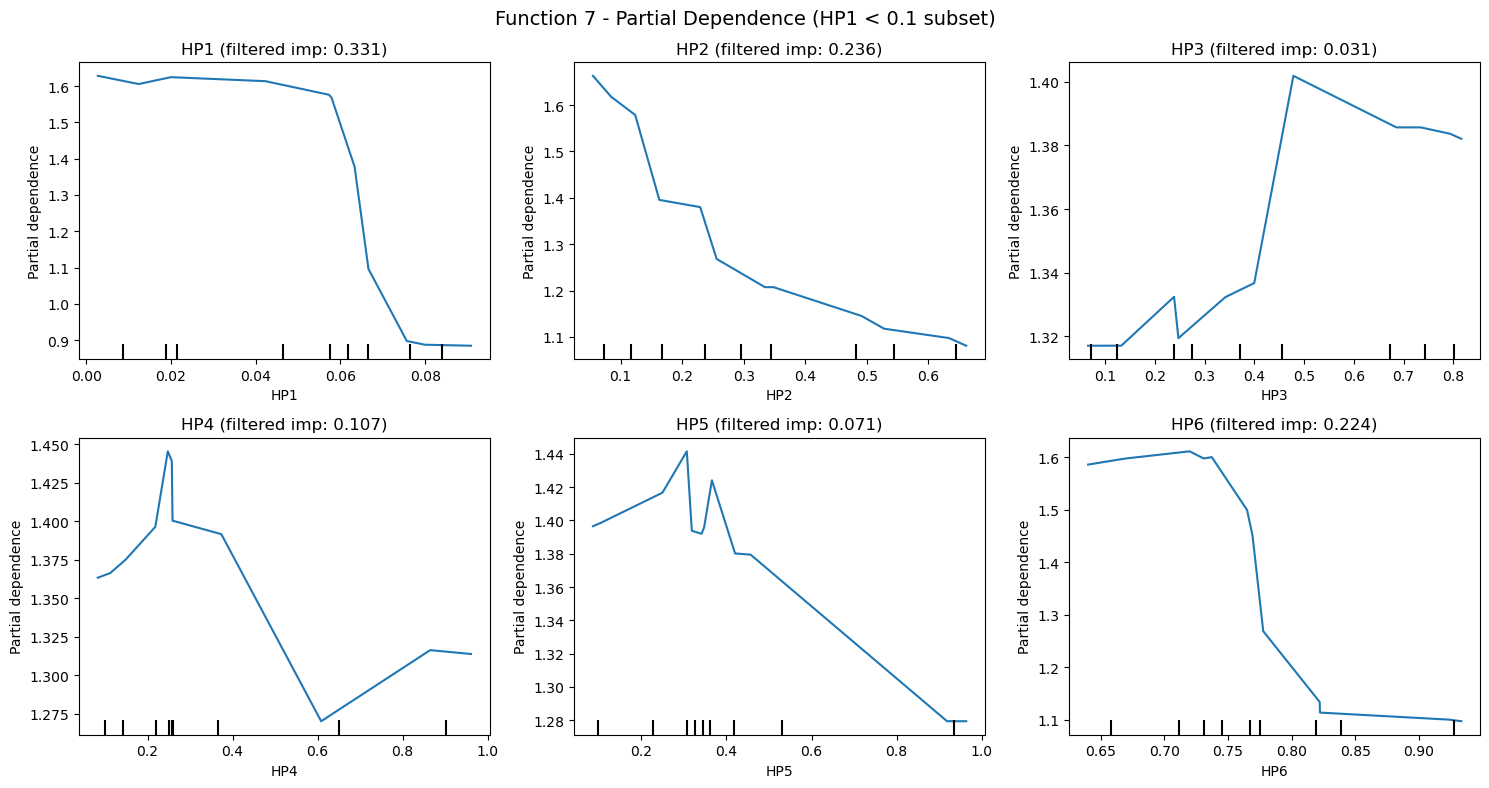

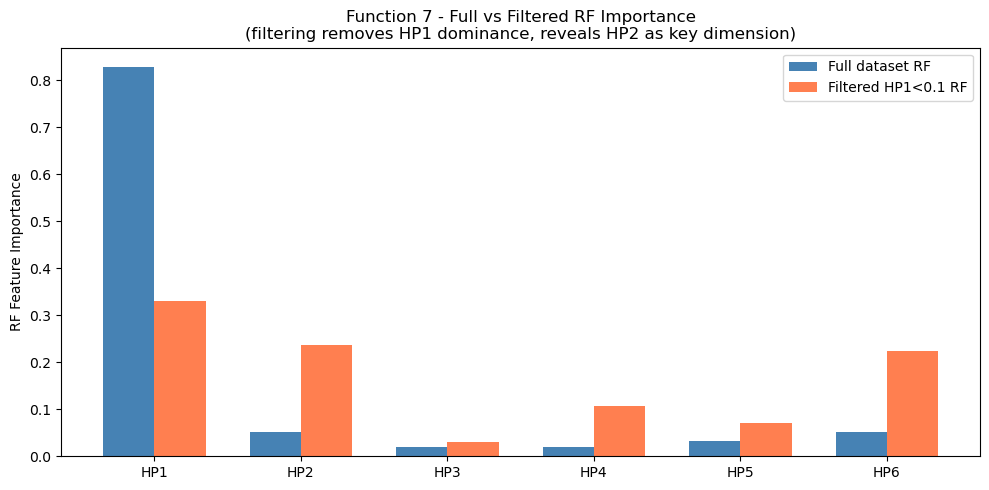

In [57]:
# --- Interpretability: Partial dependence on filtered RF ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    PartialDependenceDisplay.from_estimator(rf_filtered, filtered_inputs,
                                             features=[i],
                                             feature_names=feature_names, ax=ax)
    ax.set_title(f'{feature_names[i]} (filtered imp: {rf_filtered.feature_importances_[i]:.3f})')
plt.suptitle('Function 7 - Partial Dependence (HP1 < 0.1 subset)', fontsize=14)
plt.tight_layout()
plt.show()

# --- Interpretability: full vs filtered importance comparison ---
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(6)
width_bar = 0.35
ax.bar(x_pos - width_bar/2, rf_full.feature_importances_, width_bar, label='Full dataset RF', color='steelblue')
ax.bar(x_pos + width_bar/2, rf_filtered.feature_importances_, width_bar, label='Filtered HP1<0.1 RF', color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names)
ax.set_ylabel('RF Feature Importance')
ax.set_title('Function 7 - Full vs Filtered RF Importance\n(filtering removes HP1 dominance, reveals HP2 as key dimension)')
ax.legend()
plt.tight_layout()
plt.show()

# Function 8, Unspecified field, 8D array, 40 original samples - Week 10

In [58]:
# =============================================================================
# Function 8, Unspecified field, 8D array, 40 original samples
# =============================================================================
# Previous weeks
# W3: Pipeline (a) combines partial exploration (free dimensions) with strong exploitation (pinned dimensions); 
#     Pipeline (b) is almost entirely exploitation-focused.
# W4: GP (ARD Matérn) UCB (κ = 2.0) + MLP regressor (50/50 blend)
# W5: MC-Dropout MLP (2 hidden layers, dropout active during inference with 50 stochastic forward passes); acquisition = UCB (κ = 3.0)
# W6: Dropout MLP (8→24→24→1); Standard scaling; UCB via MC-dropout uncertainty
# W7: MC-Dropout MLP; Dropout = 0.2; hidden units = 24; UCB κ = 1.7; SHAP-scaled noise; 
#     HAP-informed candidate generation to guide exploration
# W8: MC-Dropout MLP + UCB with adaptive κ (κ_base × calibration ratio)
# W9: NN surrogate with MC dropout uncertainty; learned latent representations and stochastic uncertainty estimates

# change: Utilise an MC-Dropout MLP with weighted loss functions and adaptive acquisition scaling 
#         to prioritise high-value regions in high dimensions.

print("\n" + "=" * 60)
print("Function 8 - Week 10")
print("=" * 60)

f8_inputs  = np.load('initial_data/function_8/initial_inputs.npy')
f8_outputs = np.load('initial_data/function_8/initial_outputs.npy')

prev_queries_F8 = np.array([
    [0.034736, 0.033935, 0.577646, 0.735810, 0.807192, 0.026536, 0.72178, 0.629862],     #W2
    [0.019981, 0.000000, 0.999999, 0.000000, 0.448273, 0.855526, 0.446219, 0.931836],    #W3
    [0.035148, 0.000000, 0.018976, 0.000000, 0.999999, 0.361194, 0.007310, 0.000000],    #W4
    [0.040725, 0.748531, 0.178080, 0.981020, 0.988831, 0.993927, 0.013038, 0.216952],    #W5
    [0.060495, 0.027090, 0.006185, 0.132068, 0.160719, 0.354431, 0.001361, 0.931902],    #W6
    [0.000000, 0.009147, 0.046571, 0.113147, 0.150211, 0.340739, 0.038068, 0.928497],    #W7
    [0.007786, 0.000000, 0.000000, 0.000000, 0.999999, 0.368073, 0.022080, 0.018153],    #W8
    [0.000000, 0.000000, 0.001701, 0.357817, 0.997203, 0.357817, 0.357817, 0.002035],    #W9
])
prev_outputs_F8 = np.array([8.26488,                    #W2 (fail)
                            7.35099,                    #W3 (fail)
                            9.76008,                    #W4 (above initial max, so far the best)
                            8.590830,                   #W5 (fail)
                            9.619999,                   #W6 (above initial max)
                            9.638210,                   #W7 (above initial max)
                            9.752723,                   #W8 (above initial max)
                            9.730200,                   #W9 (above initial max)
                           ])

all_inputs_F8  = np.vstack([f8_inputs, prev_queries_F8])
all_outputs_F8 = np.hstack([f8_outputs, prev_outputs_F8])

print(f"Total points: {len(all_outputs_F8)}, best: {all_outputs_F8.max():.4f}")


Function 8 - Week 10
Total points: 48, best: 9.7601


In [59]:
# Standardise inputs/outputs and build the tensors used to train 
# the MC-Dropout MLP surrogate for Function 8 (network architecture defined just below).

scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_sc = scaler_x.fit_transform(all_inputs_F8)
Y_sc = scaler_y.fit_transform(all_outputs_F8.reshape(-1, 1)).ravel()

X_tensor = torch.tensor(X_sc, dtype=torch.float32)
Y_tensor = torch.tensor(Y_sc, dtype=torch.float32).unsqueeze(1)

# MLP: hidden=24, dropout=0.25 (increased from 0.2 for better calibration)
class DropoutMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x)

In [60]:
# LOO CV with dropout=0.25
loo_errors = []
loo_sigmas = []

for i in range(len(all_outputs_F8)):
    X_train_loo = np.delete(all_inputs_F8, i, axis=0)
    y_train_loo = np.delete(all_outputs_F8, i)
    X_test_loo  = all_inputs_F8[i:i+1]
    y_test_loo  = all_outputs_F8[i]

    sx_loo = StandardScaler()
    sy_loo = StandardScaler()
    X_tr_sc_loo = sx_loo.fit_transform(X_train_loo)
    y_tr_sc_loo = sy_loo.fit_transform(y_train_loo.reshape(-1, 1)).ravel()
    X_te_sc_loo = sx_loo.transform(X_test_loo)

    X_tr_tensor = torch.tensor(X_tr_sc_loo, dtype=torch.float32)
    Y_tr_tensor = torch.tensor(y_tr_sc_loo, dtype=torch.float32).unsqueeze(1)
    X_te_tensor = torch.tensor(X_te_sc_loo, dtype=torch.float32)

    torch.manual_seed(42)
    model_loo     = DropoutMLP(input_dim=8, hidden_dim=24, dropout_rate=0.25)
    optimiser_loo = torch.optim.Adam(model_loo.parameters(), lr=1e-3)

    model_loo.train()
    for epoch in range(1000):
        optimiser_loo.zero_grad()
        loss_loo = nn.MSELoss()(model_loo(X_tr_tensor), Y_tr_tensor)
        loss_loo.backward()
        optimiser_loo.step()

    mu_sc_loo, sigma_sc_loo = mc_predict(model_loo, X_te_tensor, n_passes=100)
    mu_loo    = sy_loo.inverse_transform(mu_sc_loo.reshape(-1, 1)).ravel()[0]
    sigma_loo = np.atleast_1d(sigma_sc_loo)[0] * sy_loo.scale_[0]

    loo_errors.append(abs(mu_loo - y_test_loo))
    loo_sigmas.append(sigma_loo)

loo_errors = np.array(loo_errors)
loo_sigmas = np.array(loo_sigmas)

In [61]:
# Adaptive kappa: base * calibration ratio 
kappa_base = 1.7
cal_ratio  = loo_errors.mean() / loo_sigmas.mean()
kappa_F8      = kappa_base * cal_ratio

print(f"\nLOO Calibration (dropout=0.25):")
print(f"  mean |error|:        {loo_errors.mean():.4f}")
print(f"  std  |error|:        {loo_errors.std():.4f}")
print(f"  max  |error|:        {loo_errors.max():.4f}")
print(f"  mean sigma (LOO):    {loo_sigmas.mean():.4f}")
print(f"  ratio (error/sigma): {cal_ratio:.3f}  (1.0 = perfect calibration)")
print(f"  kappa (adaptive):    {kappa_F8:.2f}")


LOO Calibration (dropout=0.25):
  mean |error|:        0.2664
  std  |error|:        0.2812
  max  |error|:        1.2969
  mean sigma (LOO):    0.2189
  ratio (error/sigma): 1.217  (1.0 = perfect calibration)
  kappa (adaptive):    2.07


In [62]:
# --- Top-k LOO calibration analysis ---
top_k_threshold = 9.0
top_k_mask = all_outputs_F8 > top_k_threshold
top_k_indices = np.where(top_k_mask)[0]

top_k_errors = loo_errors[top_k_mask]
top_k_sigmas = loo_sigmas[top_k_mask]

top_k_cal_ratio = top_k_errors.mean() / top_k_sigmas.mean()

print(f"\nTop-k LOO Calibration (output > {top_k_threshold}):")
print(f"  n points:            {len(top_k_indices)}")
print(f"  mean |error|:        {top_k_errors.mean():.4f}")
print(f"  std  |error|:        {top_k_errors.std():.4f}")
print(f"  max  |error|:        {top_k_errors.max():.4f}")
print(f"  mean sigma:          {top_k_sigmas.mean():.4f}")
print(f"  ratio (error/sigma): {top_k_cal_ratio:.3f}")
print(f"  global ratio was:    {cal_ratio:.3f}")


Top-k LOO Calibration (output > 9.0):
  n points:            10
  mean |error|:        0.1771
  std  |error|:        0.1943
  max  |error|:        0.6297
  mean sigma:          0.2176
  ratio (error/sigma): 0.814
  global ratio was:    1.217


In [63]:
# Per-point breakdown for the top-k
print(f"\n  Per-point breakdown (top-k):")
for idx in top_k_indices:
    print(f"    point {idx:2d}: y={all_outputs_F8[idx]:.4f}, "
          f"|err|={loo_errors[idx]:.4f}, sigma={loo_sigmas[idx]:.4f}, "
          f"ratio={loo_errors[idx]/loo_sigmas[idx]:.3f}")

# --- High-error initial points: where are they? ---
high_error_initial = [14, 22, 26, 39]
print("\nHigh-error initial points (output > 9.0):")
for idx in high_error_initial:
    print(f"  point {idx}: {np.array2string(all_inputs_F8[idx], precision=3, suppress_small=True)}"
          f"  y={all_outputs_F8[idx]:.4f}  |err|={loo_errors[idx]:.4f}")

# Compare to the actual best query found so far 
best_so_far_idx = np.argmax(all_outputs_F8)
print(f"\n  Best so far (idx {best_so_far_idx}): {np.array2string(all_inputs_F8[best_so_far_idx], precision=3, suppress_small=True)}"
      f"  y={all_outputs_F8[best_so_far_idx]:.4f}")


  Per-point breakdown (top-k):
    point 14: y=9.5985, |err|=0.1904, sigma=0.2314, ratio=0.823
    point 19: y=9.0131, |err|=0.2283, sigma=0.1810, ratio=1.261
    point 22: y=9.1416, |err|=0.4155, sigma=0.1201, ratio=3.459
    point 26: y=9.3443, |err|=0.6297, sigma=0.1443, ratio=4.363
    point 39: y=9.1830, |err|=0.0078, sigma=0.1922, ratio=0.041
    point 42: y=9.7601, |err|=0.0511, sigma=0.2820, ratio=0.181
    point 44: y=9.6200, |err|=0.0151, sigma=0.2515, ratio=0.060
    point 45: y=9.6382, |err|=0.0283, sigma=0.2476, ratio=0.114
    point 46: y=9.7527, |err|=0.0360, sigma=0.2800, ratio=0.129
    point 47: y=9.7302, |err|=0.1689, sigma=0.2459, ratio=0.687

High-error initial points (output > 9.0):
  point 14: [0.056 0.066 0.023 0.039 0.404 0.801 0.488 0.893]  y=9.5985  |err|=0.1904
  point 22: [0.145 0.119 0.421 0.388 0.155 0.875 0.511 0.729]  y=9.1416  |err|=0.4155
  point 26: [0.193 0.631 0.417 0.491 0.796 0.655 0.276 0.296]  y=9.3443  |err|=0.6297
  point 39: [0.481 0.102 0.

In [64]:
# --- train final model (weighted loss, increased capacity) ---
# Weight: high-scoring points matter more
weights = np.ones(len(all_outputs_F8))
weights[all_outputs_F8 > 9.0] = 5.0
weights[all_outputs_F8 > 9.5] = 10.0
weight_tensor = torch.tensor(weights, dtype=torch.float32)

torch.manual_seed(42)
model     = DropoutMLP(input_dim=8, hidden_dim=48, dropout_rate=0.25)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train()
for epoch in range(1500):
    optimiser.zero_grad()
    pred = model(X_tensor)
    loss = (weight_tensor * (pred.squeeze() - Y_tensor.squeeze())**2).mean()
    loss.backward()
    optimiser.step()

print(f"Training loss (final, weighted): {loss.item():.6f}")

Training loss (final, weighted): 0.082462


In [65]:
# --- Weighted LOO for comparison ---
loo_errors_w = []
loo_sigmas_w = []

for i in range(len(all_outputs_F8)):
    X_train_loo = np.delete(all_inputs_F8, i, axis=0)
    y_train_loo = np.delete(all_outputs_F8, i)
    X_test_loo  = all_inputs_F8[i:i+1]
    y_test_loo  = all_outputs_F8[i]

    w_loo = np.ones(len(y_train_loo))
    w_loo[y_train_loo > 9.0] = 5.0
    w_loo[y_train_loo > 9.5] = 10.0
    w_loo_tensor = torch.tensor(w_loo, dtype=torch.float32)

    sx_loo = StandardScaler()
    sy_loo = StandardScaler()
    X_tr_sc_loo = sx_loo.fit_transform(X_train_loo)
    y_tr_sc_loo = sy_loo.fit_transform(y_train_loo.reshape(-1, 1)).ravel()
    X_te_sc_loo = sx_loo.transform(X_test_loo)

    X_tr_tensor = torch.tensor(X_tr_sc_loo, dtype=torch.float32)
    Y_tr_tensor = torch.tensor(y_tr_sc_loo, dtype=torch.float32).unsqueeze(1)
    X_te_tensor = torch.tensor(X_te_sc_loo, dtype=torch.float32)

    torch.manual_seed(42)
    model_loo     = DropoutMLP(input_dim=8, hidden_dim=48, dropout_rate=0.25)
    optimiser_loo = torch.optim.Adam(model_loo.parameters(), lr=1e-3)

    model_loo.train()
    for epoch in range(1500):
        optimiser_loo.zero_grad()
        pred_loo = model_loo(X_tr_tensor)
        loss_loo = (w_loo_tensor * (pred_loo.squeeze() - Y_tr_tensor.squeeze())**2).mean()
        loss_loo.backward()
        optimiser_loo.step()

    mu_sc_loo, sigma_sc_loo = mc_predict(model_loo, X_te_tensor, n_passes=100)
    mu_loo    = sy_loo.inverse_transform(mu_sc_loo.reshape(-1, 1)).ravel()[0]
    sigma_loo = np.atleast_1d(sigma_sc_loo)[0] * sy_loo.scale_[0]

    loo_errors_w.append(abs(mu_loo - y_test_loo))
    loo_sigmas_w.append(sigma_loo)

loo_errors_w = np.array(loo_errors_w)
loo_sigmas_w = np.array(loo_sigmas_w)

cal_ratio_w = loo_errors_w.mean() / loo_sigmas_w.mean()
kappa_w     = kappa_base * cal_ratio_w

print(f"\nWeighted LOO Calibration (hidden=48):")
print(f"  mean |error|:        {loo_errors_w.mean():.4f}")
print(f"  mean sigma:          {loo_sigmas_w.mean():.4f}")
print(f"  ratio (error/sigma): {cal_ratio_w:.3f}")
print(f"  kappa (adaptive):    {kappa_w:.2f}")


Weighted LOO Calibration (hidden=48):
  mean |error|:        0.2040
  mean sigma:          0.1950
  ratio (error/sigma): 1.046
  kappa (adaptive):    1.78


In [66]:
# Top-k breakdown (weighted model)
top_k_mask_w = all_outputs_F8 > 9.0
top_k_errors_w = loo_errors_w[top_k_mask_w]
top_k_sigmas_w = loo_sigmas_w[top_k_mask_w]
top_k_cal_w    = top_k_errors_w.mean() / top_k_sigmas_w.mean()

print(f"\nWeighted Top-k LOO (output > 9.0):")
print(f"  mean |error|:        {top_k_errors_w.mean():.4f}")
print(f"  mean sigma:          {top_k_sigmas_w.mean():.4f}")
print(f"  ratio (error/sigma): {top_k_cal_w:.3f}")
print(f"  previous top-k ratio was: 0.683")

print(f"\n  Per-point breakdown (top-k, weighted):")
top_k_indices_w = np.where(top_k_mask_w)[0]
for idx in top_k_indices_w:
    print(f"    point {idx:2d}: y={all_outputs_F8[idx]:.4f}, "
          f"|err|={loo_errors_w[idx]:.4f}, sigma={loo_sigmas_w[idx]:.4f}, "
          f"ratio={loo_errors_w[idx]/loo_sigmas_w[idx]:.3f}")


Weighted Top-k LOO (output > 9.0):
  mean |error|:        0.1223
  mean sigma:          0.1487
  ratio (error/sigma): 0.822
  previous top-k ratio was: 0.683

  Per-point breakdown (top-k, weighted):
    point 14: y=9.5985, |err|=0.0688, sigma=0.1722, ratio=0.399
    point 19: y=9.0131, |err|=0.2168, sigma=0.1328, ratio=1.633
    point 22: y=9.1416, |err|=0.2536, sigma=0.1014, ratio=2.500
    point 26: y=9.3443, |err|=0.5109, sigma=0.1162, ratio=4.396
    point 39: y=9.1830, |err|=0.0194, sigma=0.1321, ratio=0.147
    point 42: y=9.7601, |err|=0.0020, sigma=0.1732, ratio=0.012
    point 44: y=9.6200, |err|=0.0154, sigma=0.1644, ratio=0.094
    point 45: y=9.6382, |err|=0.0481, sigma=0.1601, ratio=0.300
    point 46: y=9.7527, |err|=0.0328, sigma=0.1720, ratio=0.190
    point 47: y=9.7302, |err|=0.0550, sigma=0.1628, ratio=0.338


  0%|          | 0/48 [00:00<?, ?it/s]

C:\Users\mayzu\AppData\Local\Temp\ipykernel_16916\1404941226.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sc,


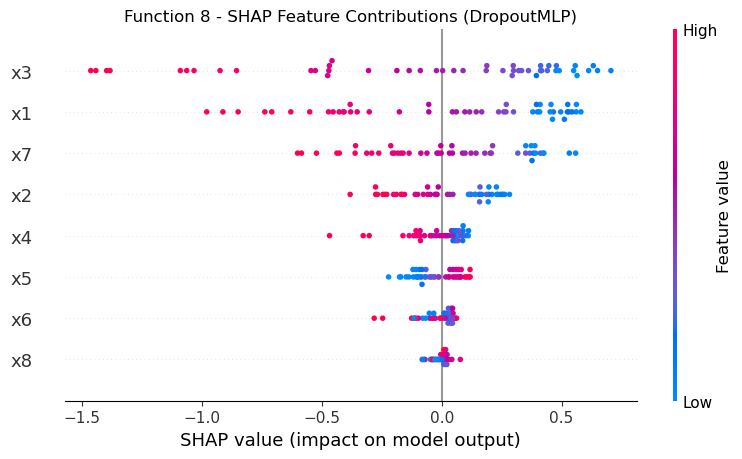

In [67]:
# --- SHAP on the DropoutMLP ---
model.eval()

def mlp_predict(X_np):
    """Wrapper for SHAP -- takes numpy array, returns numpy predictions."""
    X_t = torch.tensor(X_np, dtype=torch.float32)
    with torch.no_grad():
        preds = model(X_t).squeeze().numpy()
    return np.atleast_1d(preds)

background = X_sc[np.random.choice(len(X_sc), size=20, replace=False)]
explainer  = shap.KernelExplainer(mlp_predict, background)
shap_values = explainer.shap_values(X_sc, nsamples=100)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sc,
                  feature_names=[f'x{i+1}' for i in range(8)], show=False)
plt.title('Function 8 - SHAP Feature Contributions (DropoutMLP)')
plt.tight_layout()
plt.show()

In [68]:
model.train()  # back to train mode for MC dropout

# --- SHAP importance for noise scaling ---
shap_importance = np.abs(shap_values).mean(axis=0)
shap_importance = shap_importance / shap_importance.max()

print("\nSHAP-derived importance (normalised):")
for i in range(8):
    print(f"  x{i+1}: {shap_importance[i]:.3f}")


SHAP-derived importance (normalised):
  x1: 0.787
  x2: 0.310
  x3: 1.000
  x4: 0.164
  x5: 0.155
  x6: 0.100
  x7: 0.500
  x8: 0.047


In [69]:
# ------ trying evenly spaced pool
sampler = LatinHypercube(d=8, seed=42)
pool = sampler.random(n=50000)

# scale and predict
pool_sc     = scaler_x.transform(pool)
pool_tensor = torch.tensor(pool_sc, dtype=torch.float32)

mu_sc, sigma_sc = mc_predict(model, pool_tensor, n_passes=100)

mu_F8    = scaler_y.inverse_transform(mu_sc.reshape(-1, 1)).ravel()
sigma_F8 = sigma_sc * scaler_y.scale_[0]

# UCB with adaptive kappa
ucb_F8      = mu_F8 + kappa_w * sigma_F8
best_idx_F8 = np.argmax(ucb_F8)
query_F8    = pool[best_idx_F8]

print(f"\nmu   range: {mu_F8.min():.3f} to {mu_F8.max():.3f}")
print(f"sigma range: {sigma_F8.min():.3f} to {sigma_F8.max():.3f}")
print(f"kappa*sigma range: {(kappa_F8*sigma_F8).min():.3f} to {(kappa_F8*sigma_F8).max():.3f}")

print(f"\nWeek 10 Query: {format_query(query_F8)}")
print(f"MC mu: {mu_F8[best_idx_F8]:.4f}, sigma: {sigma_F8[best_idx_F8]:.4f}")
print(f"UCB:   {ucb_F8[best_idx_F8]:.4f}")


mu   range: 4.563 to 9.775
sigma range: 0.057 to 0.767
kappa*sigma range: 0.117 to 1.587

Week 10 Query: 0.071358-0.056561-0.038275-0.129888-0.740838-0.572688-0.045918-0.708294
MC mu: 9.7549, sigma: 0.1941
UCB:   10.1000


## Summary — this week's submissions

Collects the `query_F*` variable set in each section above, so the
final submission list is read off one place rather than re-derived by eye
from scattered print statements.

In [70]:
submissions = {
    1: query_F1,
    2: query_F2,
    3: query_F3,
    4: query_F4,
    5: query_F5,
    6: query_F6,
    7: query_F7,
    8: query_F8,
}

for fn_id, query in submissions.items():
    print(f"Function {fn_id}: {format_query(query)}")

Function 1: 0.718356-0.714455
Function 2: 0.697454-0.000000
Function 3: 0.371804-0.301322-0.451223
Function 4: 0.372317-0.403232-0.376261-0.380970
Function 5: 0.656411-1.185597-1.026548-1.160768
Function 6: 0.317166-0.547049-0.105786-1.000000-0.002390
Function 7: 0.059517-0.056546-0.864985-0.258438-0.352116-0.678089
Function 8: 0.071358-0.056561-0.038275-0.129888-0.740838-0.572688-0.045918-0.708294


# Prediction vs Actual

| Function | Prediction |     Actual |
| -------- | ---------: | ---------: |
| F1       |   7.66E-16 |   3.17e−11 |
| F2       |     0.6682 |     0.5109 |
| F3       |   −0.02768 |   −0.01852 |
| F4       |      0.814 |     0.2736 |
| F5       |  10,800.73 |  14,653.36 |
| F6       |     0.2269 | −1.0888312 |
| F7       |      2.751 |    1.76236 |
| F8       |     9.7549 |    9.90829 |


In [71]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Input Data
data = {
    'Function': ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8'],
    'Actual': [3.17e-11, 0.5109, -0.01852, 0.2736, 14653.36, -1.0888312, 1.76236, 9.90829],
    'Prediction': [7.66e-16, 0.6682, -0.02768, 0.8140, 10800.73, 0.2269, 2.7510, 9.7549]
}

df = pd.DataFrame(data)

# Convert to arrays
y_true = df['Actual'].values
y_pred = df['Prediction'].values

# 2. Element-wise Metrics
df['Absolute_Error'] = np.abs(df['Prediction'] - df['Actual'])
# Adding epsilon (1e-15) prevents division-by-zero if an actual value is 0
df['Relative_Error'] = df['Absolute_Error'] / np.abs(df['Actual']) 
df['Percentage_Error (%)'] = df['Relative_Error'] * 100

print("=== Element-wise Metric Table ===")
print(df[['Function', 'Actual', 'Prediction', 'Absolute_Error', 'Percentage_Error (%)']])
print("\n" + "="*50 + "\n")

# 3. Global Summary Metrics
mae = mean_absolute_error(y_true, y_pred)
# root_mean_squared_error is standard in newer scikit-learn versions; 
# np.sqrt(mean_squared_error) works on all versions
rmse = np.sqrt(mean_squared_error(y_true, y_pred)) 
r2 = r2_score(y_true, y_pred)
mape = np.mean(df['Relative_Error']) * 100

print("=== Global Summary Metrics ===")
print(f"MAE (Mean Absolute Error)          : {mae:.6f}")
print(f"RMSE (Root Mean Squared Error)     : {rmse:.6f}")
print(f"R² Score                           : {r2:.6f}")
print(f"MAPE (Mean Absolute Percent Error) : {mape:.2f}%")

=== Element-wise Metric Table ===
  Function        Actual    Prediction  Absolute_Error  Percentage_Error (%)
0       F1  3.170000e-11  7.660000e-16    3.169923e-11             99.997584
1       F2  5.109000e-01  6.682000e-01    1.573000e-01             30.788804
2       F3 -1.852000e-02 -2.768000e-02    9.160000e-03             49.460043
3       F4  2.736000e-01  8.140000e-01    5.404000e-01            197.514620
4       F5  1.465336e+04  1.080073e+04    3.852630e+03             26.291786
5       F6 -1.088831e+00  2.269000e-01    1.315731e+00            120.838859
6       F7  1.762360e+00  2.751000e+00    9.886400e-01             56.097506
7       F8  9.908290e+00  9.754900e+00    1.533900e-01              1.548098


=== Global Summary Metrics ===
MAE (Mean Absolute Error)          : 481.974328
RMSE (Root Mean Squared Error)     : 1362.110539
R² Score                           : 0.920982
MAPE (Mean Absolute Percent Error) : 72.82%


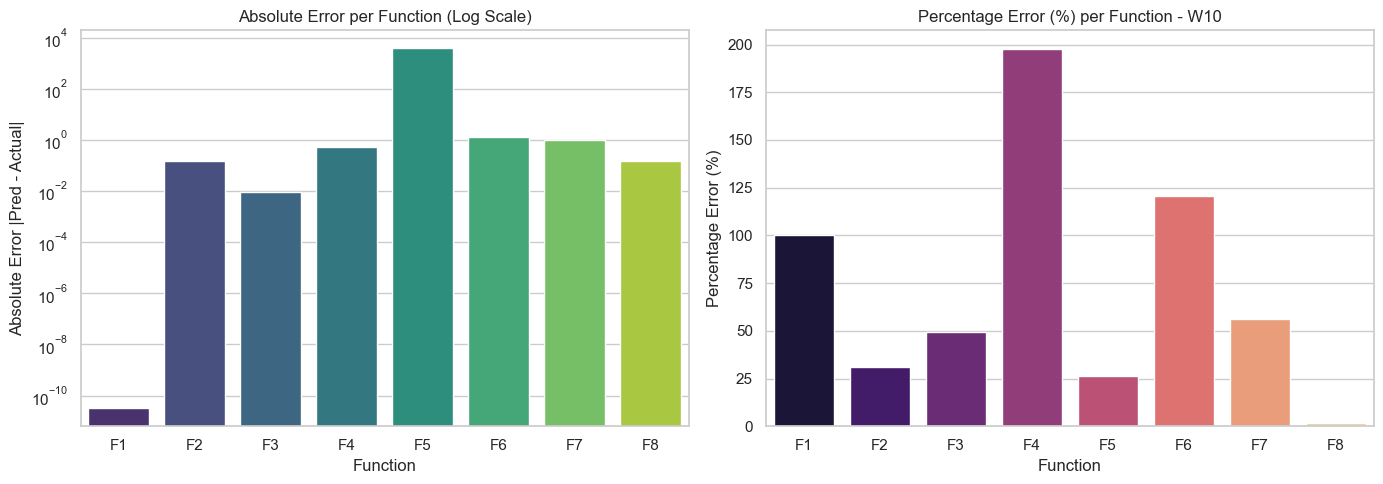

In [72]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


df = pd.DataFrame(data)
df['Absolute_Error'] = np.abs(df['Prediction'] - df['Actual'])
df['Percentage_Error'] = (df['Absolute_Error'] / np.abs(df['Actual'])) * 100

# Set theme
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Absolute Error (Log Scale) — Updated with hue and legend=False
sns.barplot(
    data=df, 
    x='Function', 
    y='Absolute_Error', 
    hue='Function', 
    palette='viridis', 
    legend=False, 
    ax=axes[0]
)
axes[0].set_yscale('log')
axes[0].set_title('Absolute Error per Function (Log Scale)')
axes[0].set_ylabel('Absolute Error |Pred - Actual|')

# Plot 2: Percentage Error — Updated with hue and legend=False
sns.barplot(
    data=df, 
    x='Function', 
    y='Percentage_Error', 
    hue='Function', 
    palette='magma', 
    legend=False, 
    ax=axes[1]
)
axes[1].set_title('Percentage Error (%) per Function - W10')
axes[1].set_ylabel('Percentage Error (%)')

plt.tight_layout()
plt.show()